# awal awal

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and Io/J0 map existing: 274
Rows removed due to missing high image or Io/J0 map: 316

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             io_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  

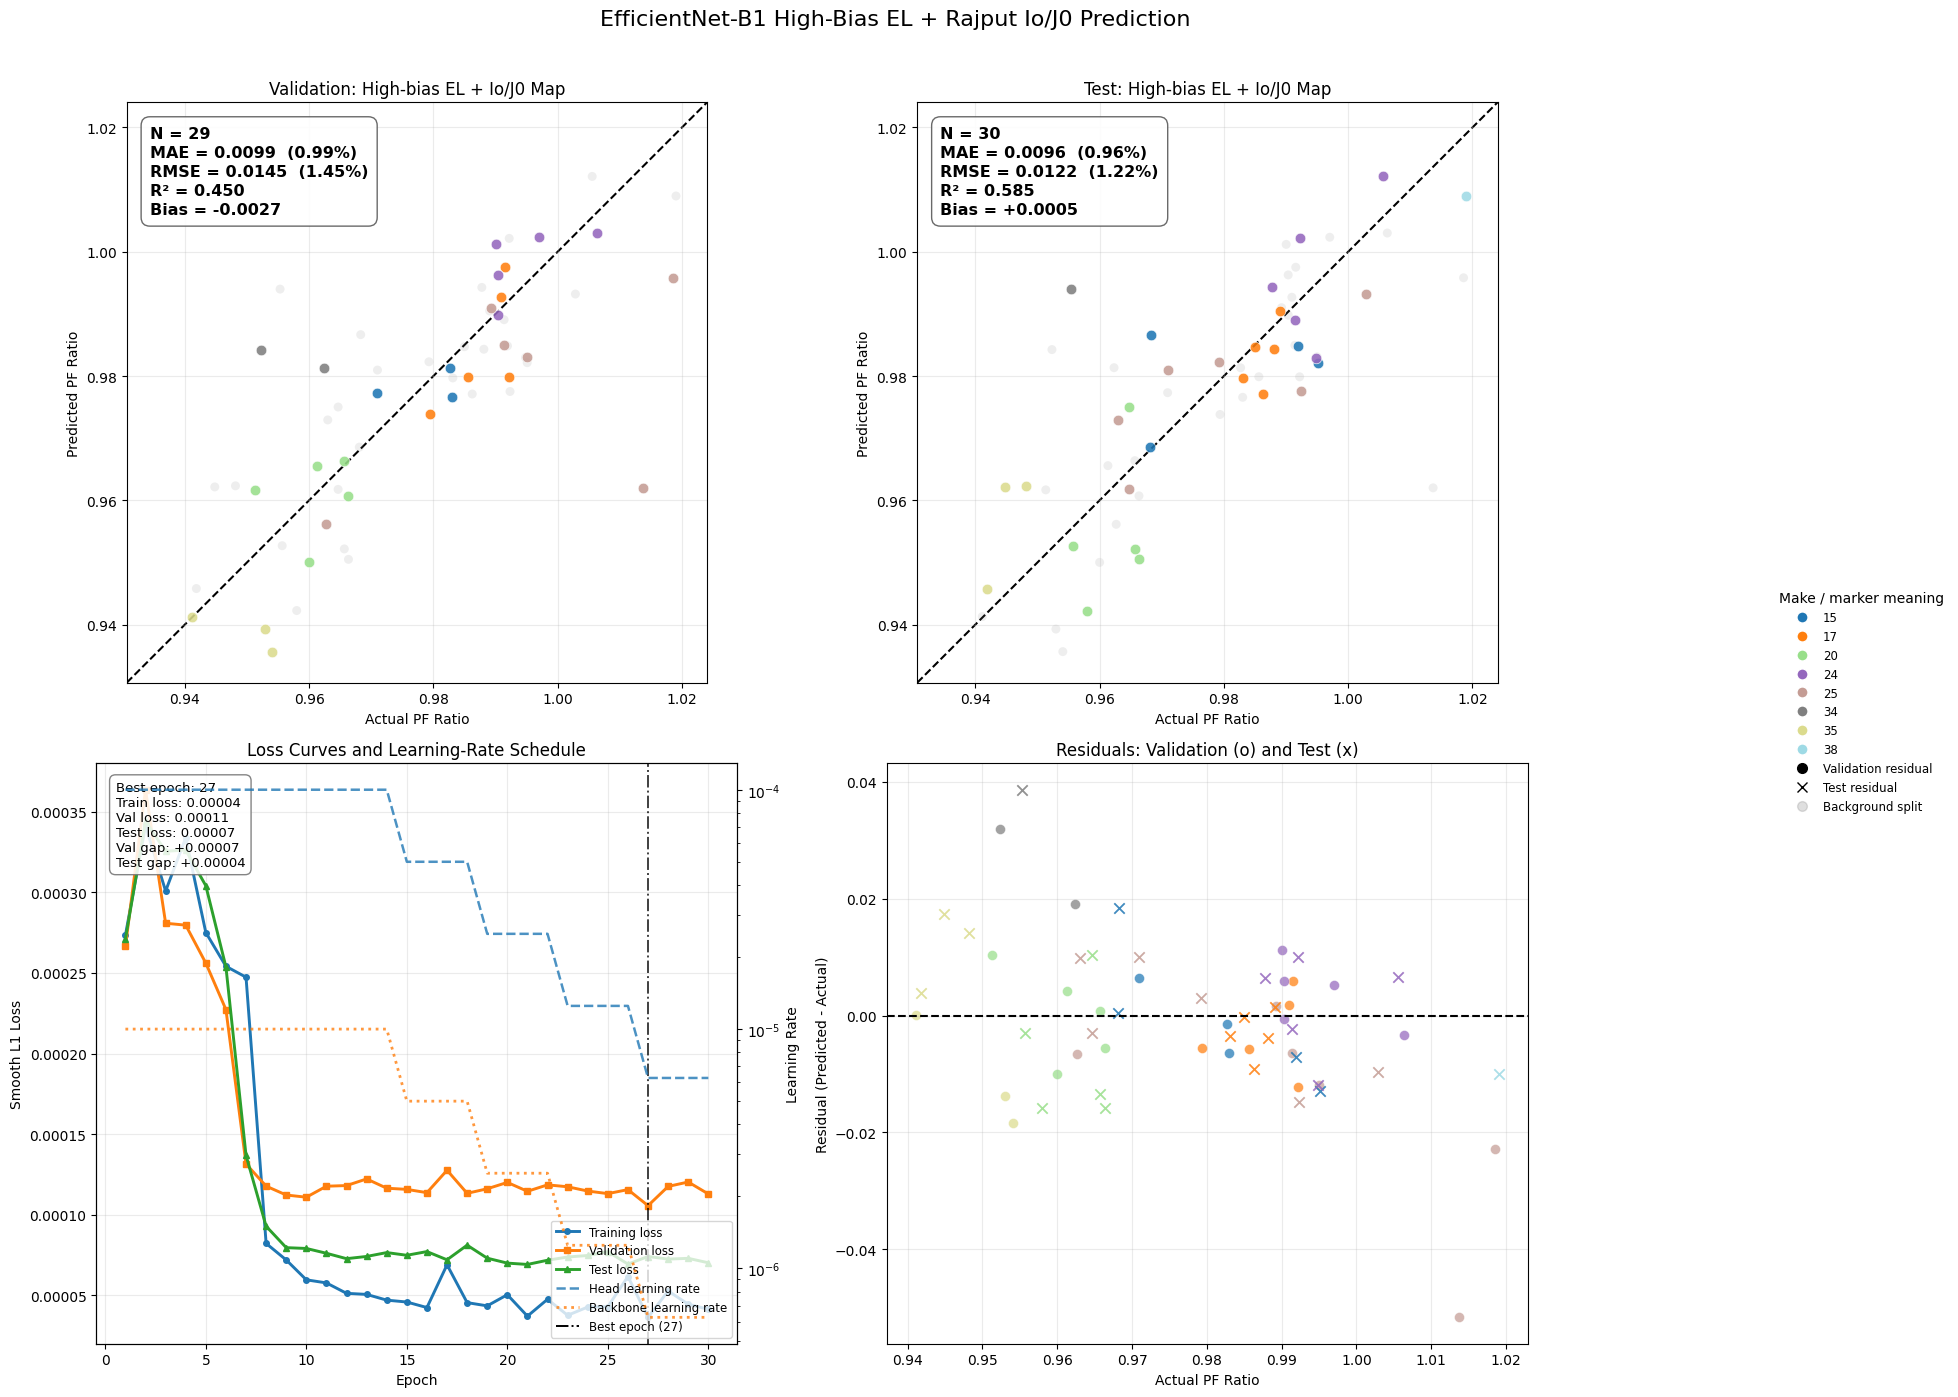


Saved:
- results_effnet_b1_highbias_io_fixedsplit_generalization.png
- validation_predictions_effnet_b1_highbias_io_fixedsplit.csv
- test_predictions_effnet_b1_highbias_io_fixedsplit.csv
- metrics_per_make_effnet_b1_highbias_io_fixedsplit.csv
- training_history_effnet_b1_highbias_io_fixedsplit.csv
- effnet_b1_highbias_io_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput Io/J0 maps, relative to CSV directory.
# Expected filenames:
#   base_name_Io.tiff
# or fallback:
#   base_name_J0.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# EfficientNet-B1 native input size
IMAGE_SIZE = 240

# If CUDA out of memory, reduce to 8 or 4.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_io_path(elh_path_str, base_dir):
    # Derive Rajput Io map path from ELHPath.
    # Fallback to J0 map if Io map does not exist.
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    io_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    j0_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    if not os.path.exists(io_path) and os.path.exists(j0_fallback):
        io_path = j0_fallback

    return io_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["io_path"] = df["ELHPath"].apply(
        lambda p: derive_io_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["io_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["io_exists"] = df["io_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["io_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and Io/J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or Io/J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "io_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load Io/J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def robust_normalize_map(img, lower_percentile=1.0, upper_percentile=99.0):
    img = img.astype(np.float32)
    finite = img[np.isfinite(img)]

    if finite.size == 0:
        return np.zeros_like(img, dtype=np.float32)

    low = np.percentile(finite, lower_percentile)
    high = np.percentile(finite, upper_percentile)

    if high - low <= 1e-12:
        return np.zeros_like(img, dtype=np.float32)

    clipped = np.clip(img, low, high)

    return ((clipped - low) / (high - low)).astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput Io/J0 map
# =========================================================
class HighBiasIoDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, io map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        self.cache_io = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                io_map = read_physics_map(row["io_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size
                )

                self.cache_io[i] = resize_with_padding_float(
                    io_map,
                    self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_io[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_io.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, io_map):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            io_map = cv2.flip(io_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            io_map = cv2.flip(io_map, 0)

        return high_img, io_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            io_map = self.cache_io[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            io_map = read_physics_map(row["io_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            io_map = resize_with_padding_float(io_map, self.image_size)

        if self.augment:
            high_img, io_map = self.apply_same_augmentation(high_img, io_map)

        # Channel 0: high-bias EL image
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput Io/J0 map
        io_map = robust_normalize_map(io_map)

        high_img = np.expand_dims(high_img, axis=0)
        io_map = np.expand_dims(io_map, axis=0)

        x = np.concatenate([high_img, io_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: EfficientNet-B1, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput Io/J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + Io/J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and Io/J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and Io/J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput Io/J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and Io/J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = HighBiasIoDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_dataset = HighBiasIoDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_dataset = HighBiasIoDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, high-bias EL + Rajput Io/J0 map")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation"
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + Io/J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + Io/J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual"
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 High-Bias EL + Rajput Io/J0 Prediction",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b1_highbias_io_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_highbias_io_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_highbias_io_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_highbias_io_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_highbias_io_fixedsplit.csv"
    model_path = "effnet_b1_highbias_io_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation"
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test"
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# Yang cuma 60

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and Io/J0 map existing: 274
Rows removed due to missing high image or Io/J0 map: 316

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             io_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  

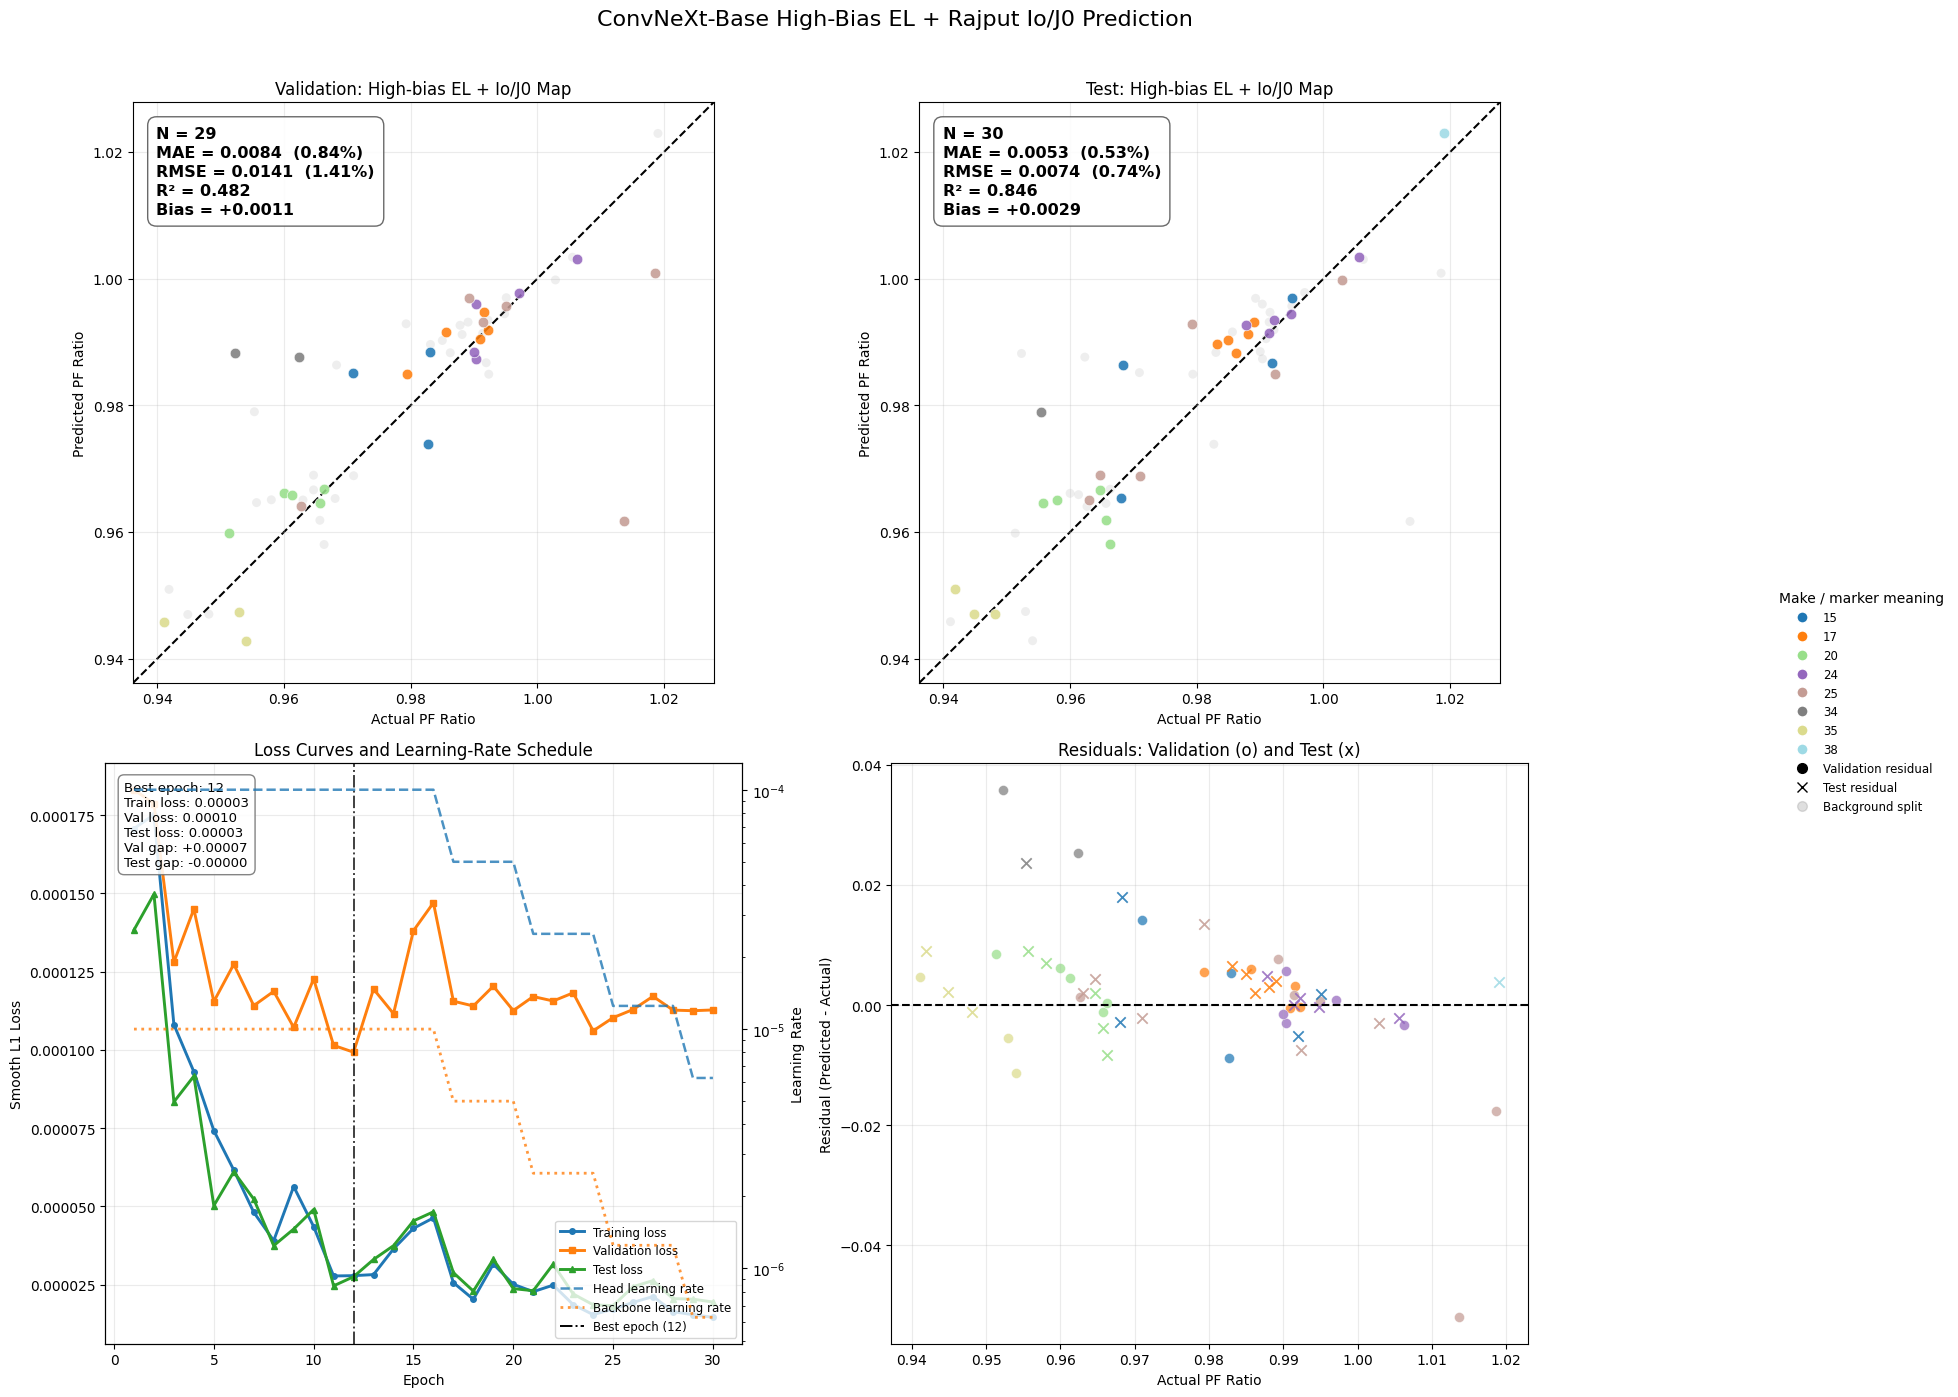


Saved:
- results_convnext_base_highbias_io_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_io_fixedsplit.csv
- test_predictions_convnext_base_highbias_io_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_io_fixedsplit.csv
- training_history_convnext_base_highbias_io_fixedsplit.csv
- convnext_base_highbias_io_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput Io/J0 maps, relative to CSV directory.
# Expected filenames:
#   base_name_Io.tiff
# or fallback:
#   base_name_J0.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavier than EfficientNet-B1.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_io_path(elh_path_str, base_dir):
    # Derive Rajput Io map path from ELHPath.
    # Fallback to J0 map if Io map does not exist.
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    io_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    j0_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    if not os.path.exists(io_path) and os.path.exists(j0_fallback):
        io_path = j0_fallback

    return io_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["io_path"] = df["ELHPath"].apply(
        lambda p: derive_io_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["io_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["io_exists"] = df["io_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["io_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and Io/J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or Io/J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "io_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load Io/J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def robust_normalize_map(img, lower_percentile=1.0, upper_percentile=99.0):
    img = img.astype(np.float32)
    finite = img[np.isfinite(img)]

    if finite.size == 0:
        return np.zeros_like(img, dtype=np.float32)

    low = np.percentile(finite, lower_percentile)
    high = np.percentile(finite, upper_percentile)

    if high - low <= 1e-12:
        return np.zeros_like(img, dtype=np.float32)

    clipped = np.clip(img, low, high)

    return ((clipped - low) / (high - low)).astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput Io/J0 map
# =========================================================
class HighBiasIoDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, io map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        self.cache_io = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                io_map = read_physics_map(row["io_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size
                )

                self.cache_io[i] = resize_with_padding_float(
                    io_map,
                    self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_io[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_io.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, io_map):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            io_map = cv2.flip(io_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            io_map = cv2.flip(io_map, 0)

        return high_img, io_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            io_map = self.cache_io[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            io_map = read_physics_map(row["io_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            io_map = resize_with_padding_float(io_map, self.image_size)

        if self.augment:
            high_img, io_map = self.apply_same_augmentation(high_img, io_map)

        # Channel 0: high-bias EL image
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput Io/J0 map
        io_map = robust_normalize_map(io_map)

        high_img = np.expand_dims(high_img, axis=0)
        io_map = np.expand_dims(io_map, axis=0)

        x = np.concatenate([high_img, io_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput Io/J0 map
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20
    )

    return model

# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput Io/J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + Io/J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and Io/J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and Io/J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput Io/J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and Io/J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = HighBiasIoDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_dataset = HighBiasIoDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_dataset = HighBiasIoDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput Io/J0 map")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation"
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + Io/J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + Io/J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual"
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput Io/J0 Prediction",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_convnext_base_highbias_io_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_io_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_io_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_io_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_io_fixedsplit.csv"
    model_path = "convnext_base_highbias_io_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation"
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test"
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# Convnext Ini yang normalized pada seluruh modul 60 biji

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 274
Rows removed due to missing high image or J0 map: 316

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

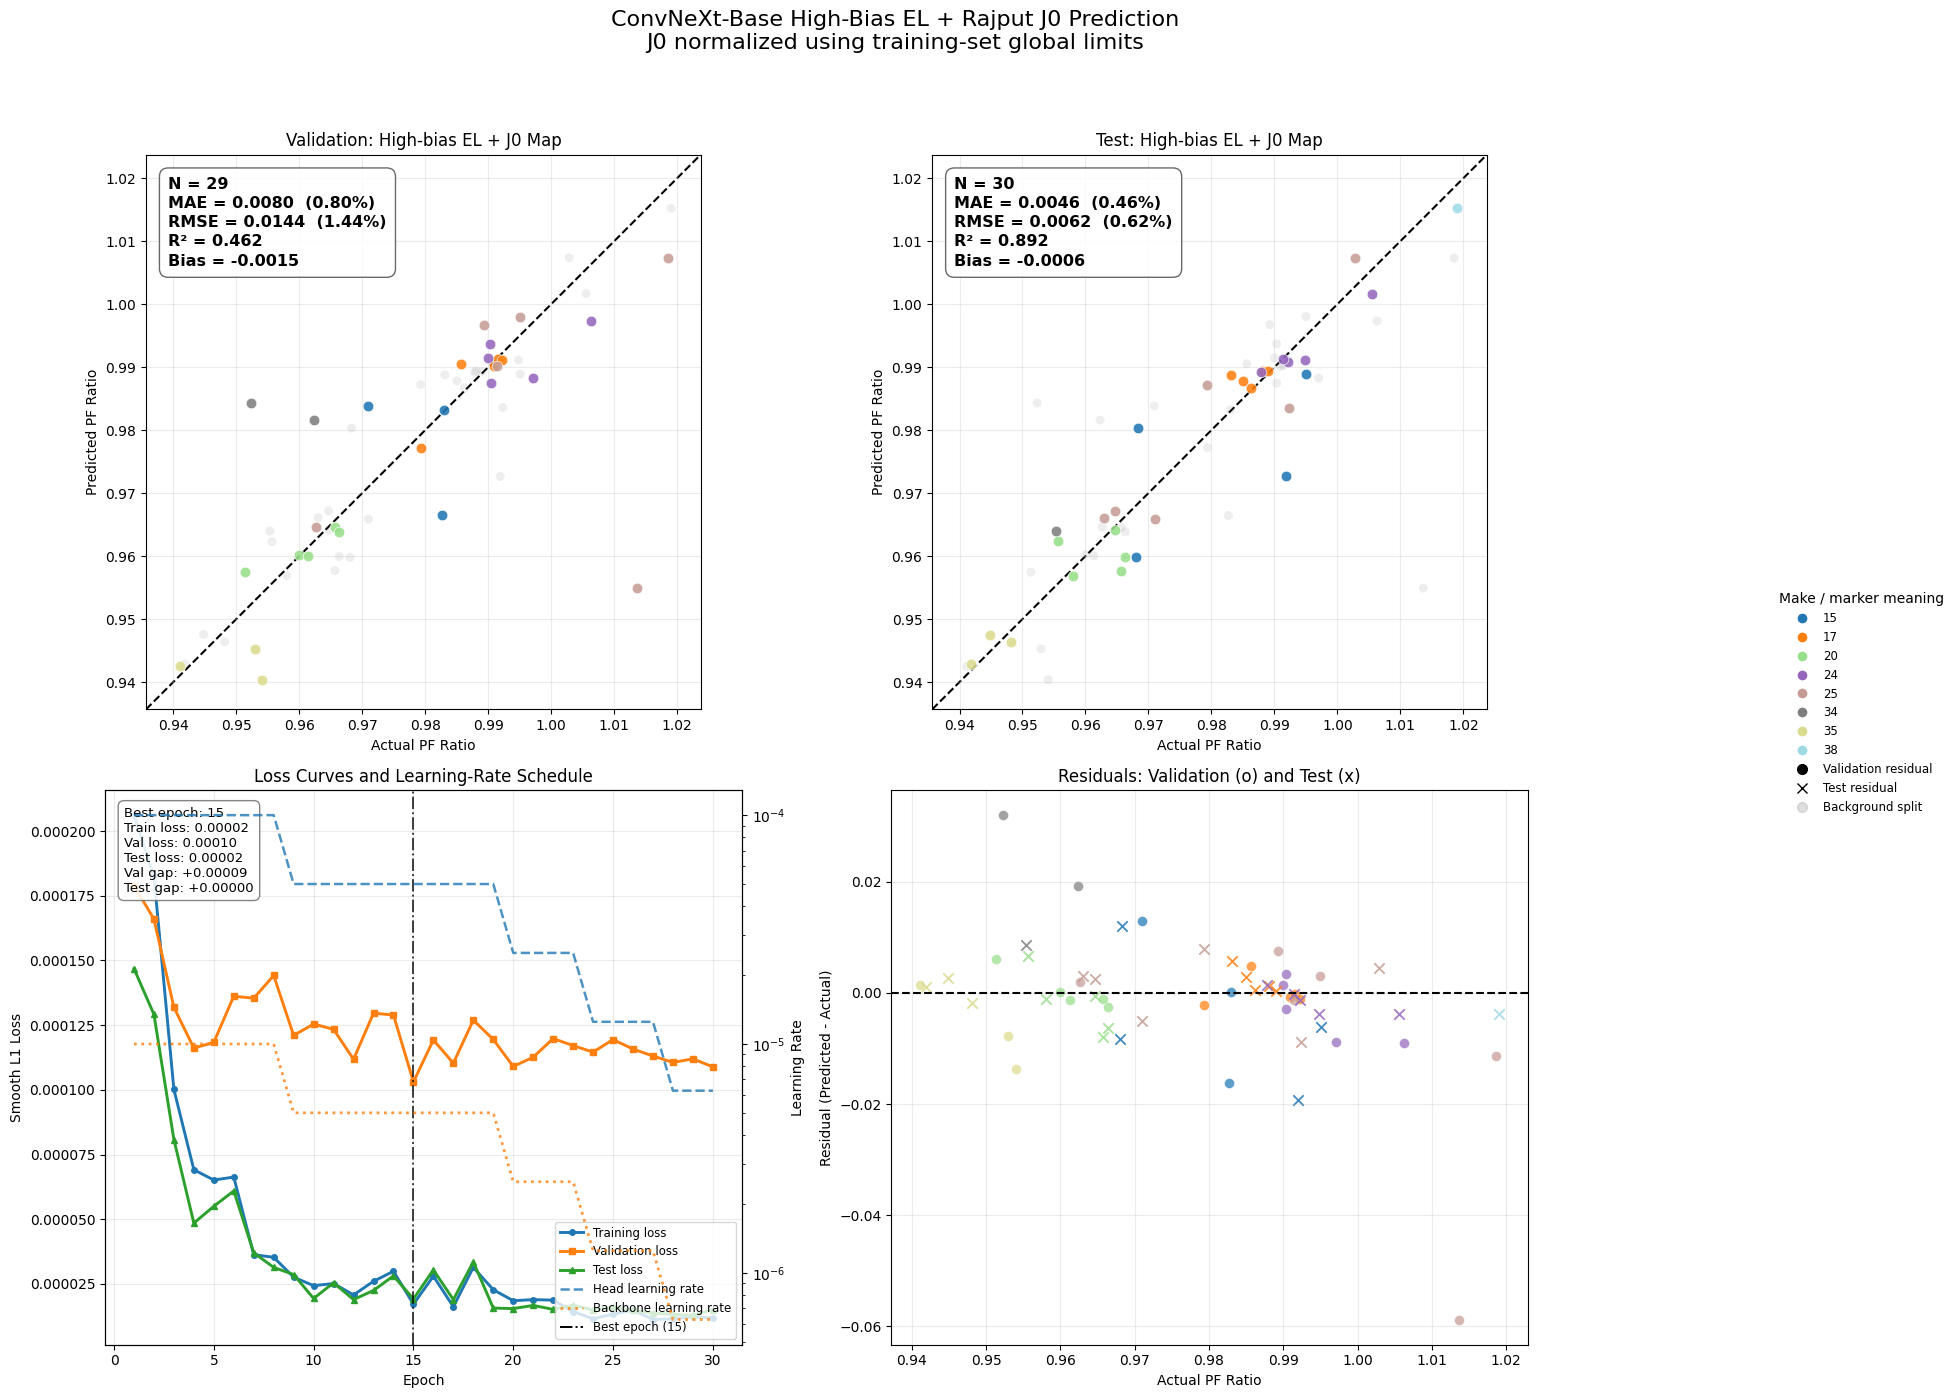


Saved:
- results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# ini yang normalized effnet B1 

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 274
Rows removed due to missing high image or J0 map: 316

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

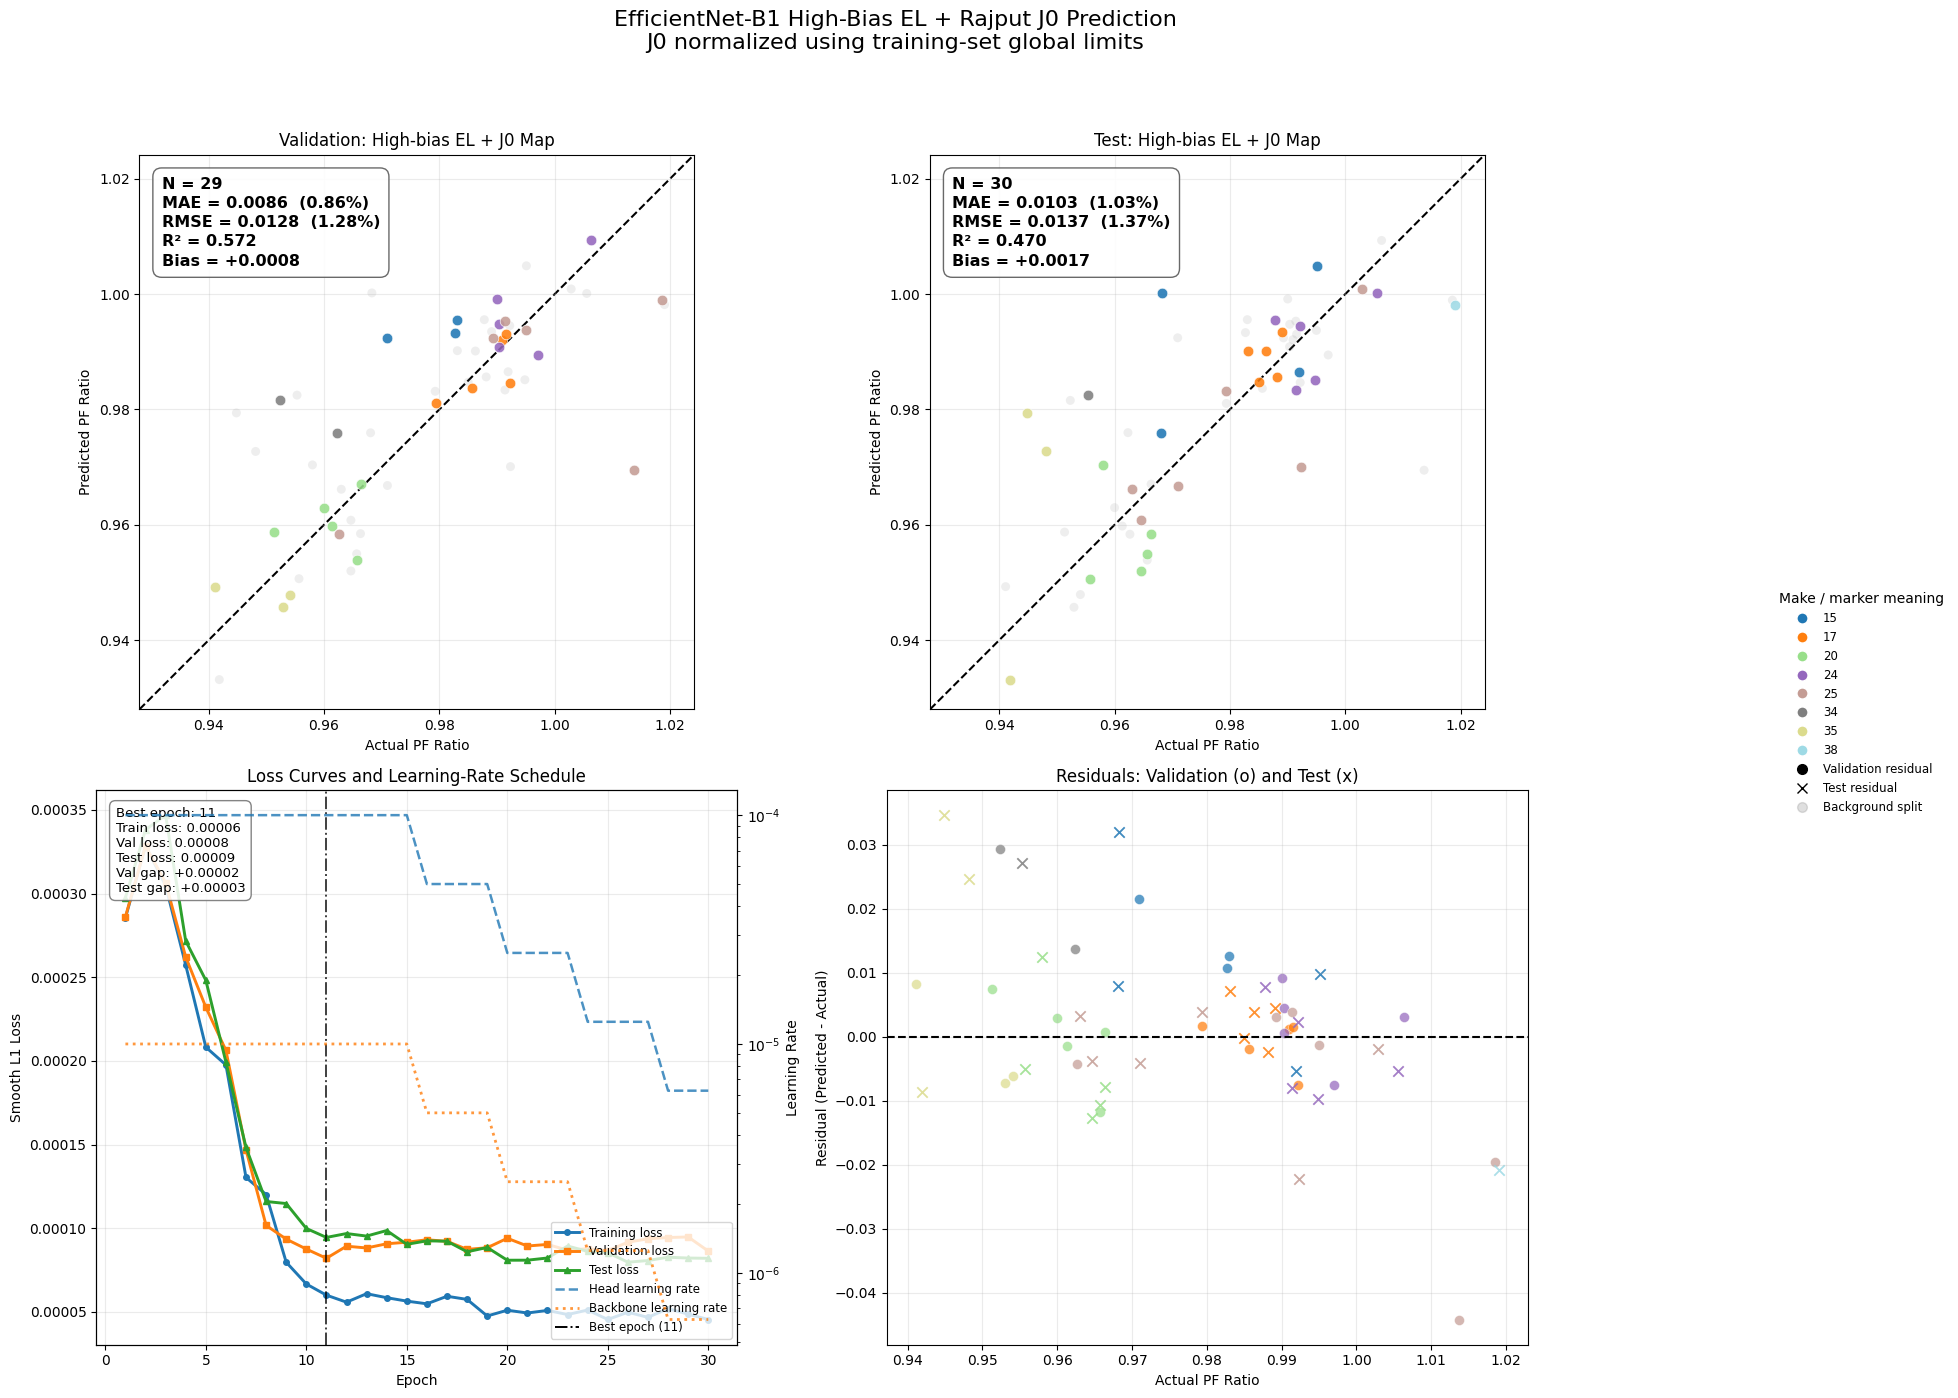


Saved:
- results_effnet_b1_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv
- training_history_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_effnet_b1_highbias_j0.csv
- effnet_b1_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [3]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# EfficientNet-B1 native input size
IMAGE_SIZE = 240

# EfficientNet-B1 is lighter than ConvNeXt-Base.
# If CUDA out of memory, reduce to 8 or 4.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: EfficientNet-B1, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """
    EfficientNet-B1 modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    # EfficientNet-B1 first convolution:
    # model.features[0][0] = Conv2dNormActivation with Conv2d at index 0.
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
        padding_mode=old_conv.padding_mode,
    )

    with torch.no_grad():
        if pretrained:
            # Convert RGB ImageNet filters to grayscale-like filters,
            # then initialise both input channels with the same averaged filter.
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean

            # Keep the first-layer activation scale roughly similar for two channels.
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if new_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # EfficientNet classifier: Dropout + Linear
    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model

# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, high-bias EL + Rajput J0 map (train-set global normalization)")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_effnet_b1_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_effnet_b1_highbias_j0.csv"
    model_path = "effnet_b1_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# ConvNext make split

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 274
Rows with both high-bias image and J0 map existing: 274
Rows removed due to missing high image or J0 map: 0

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users

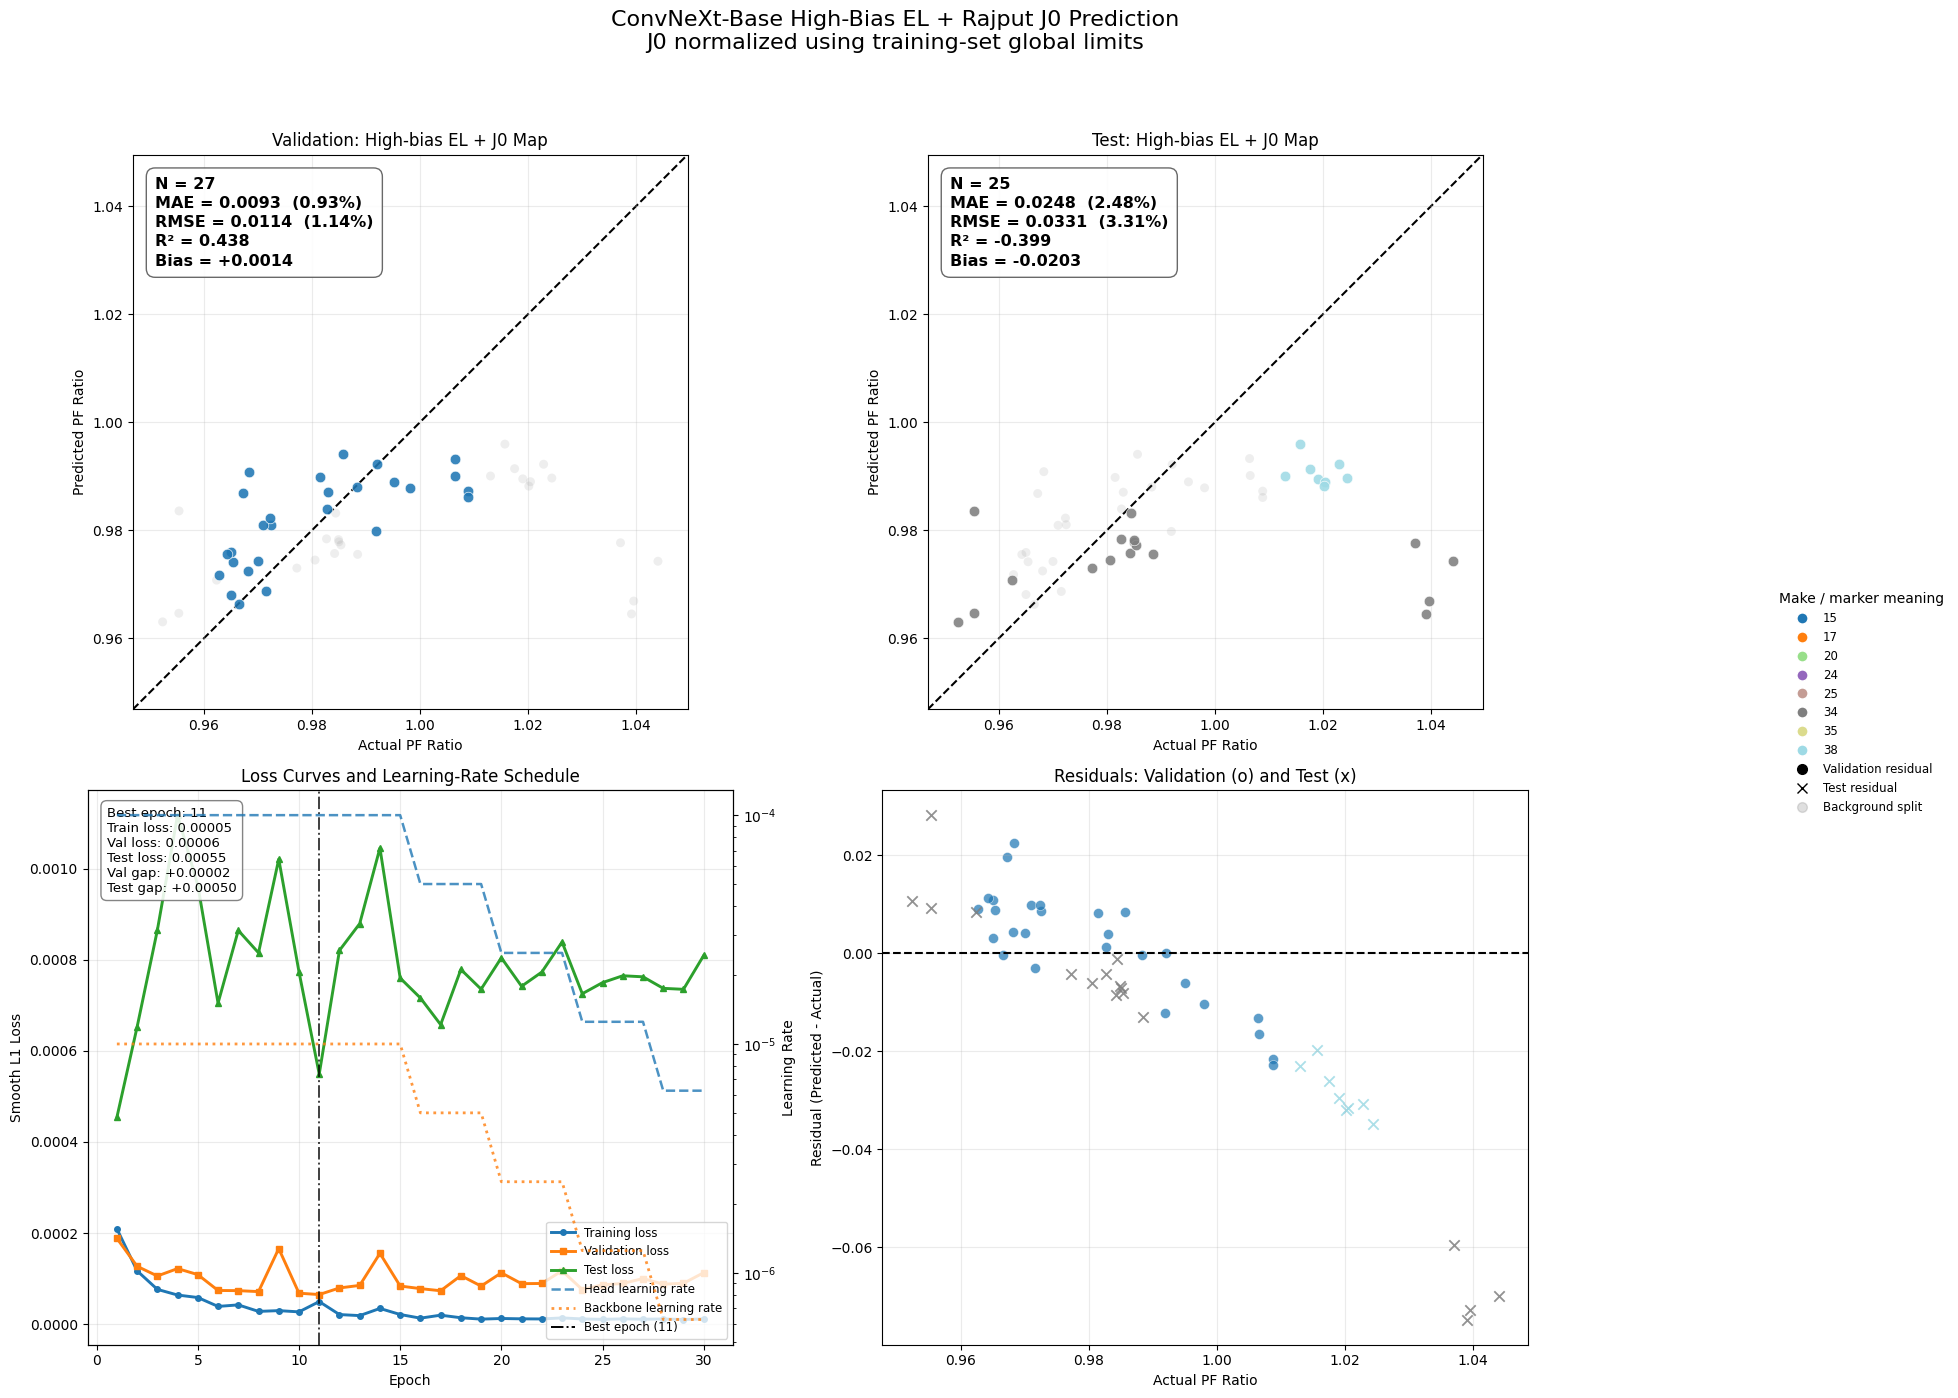


Saved:
- results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [3]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42_rajput_eligible_make_disjoint_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas

J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)

def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Robust log-domain J0 limits from the TRAINING SET ONLY.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    Background/padding/invalid pixels (<= J0_FLOOR) are excluded so they
    do not anchor the lower limit.
    """
    print("\nComputing global log-domain J0 limits from training set only...")

    all_log_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        # keep only physically meaningful, strictly positive active pixels
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in the training set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(f"Training-set log10(J0) p{lower_percentile:g}: {log_lower:.4f} "
          f"({10**log_lower:.3e} A/px)")
    print(f"Training-set log10(J0) p{upper_percentile:g}: {log_upper:.4f} "
          f"({10**log_upper:.3e} A/px)")
    print(f"Active training pixels used: {all_log_values.size:,}")

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization to [0, 1] using training-set limits.

    Background/invalid pixels (<= floor) are mapped to 0.0. Active pixels are
    log10-scaled, clipped to the training percentile band, then linearly mapped
    to (0, 1]. This preserves contrast across the J0 spike instead of squashing
    it against the padding value.
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10**log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    # map active pixels into (0, 1]; keep background at exactly 0 so the network
    # can still distinguish "no cell" from "low-J0 cell"
    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


"AnonDB_normal_trainval_unseen_make_test_seed42.csv"

# ini by make terakhir 

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 274
Rows removed due to missing high image or J0 map: 316

Sample rows:
   Make make_plot  split                                          high_path  \
0    17        17  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    20        20  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    20        20  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    20        20  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    24        24  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.992500  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.963333  
2  c:\Use

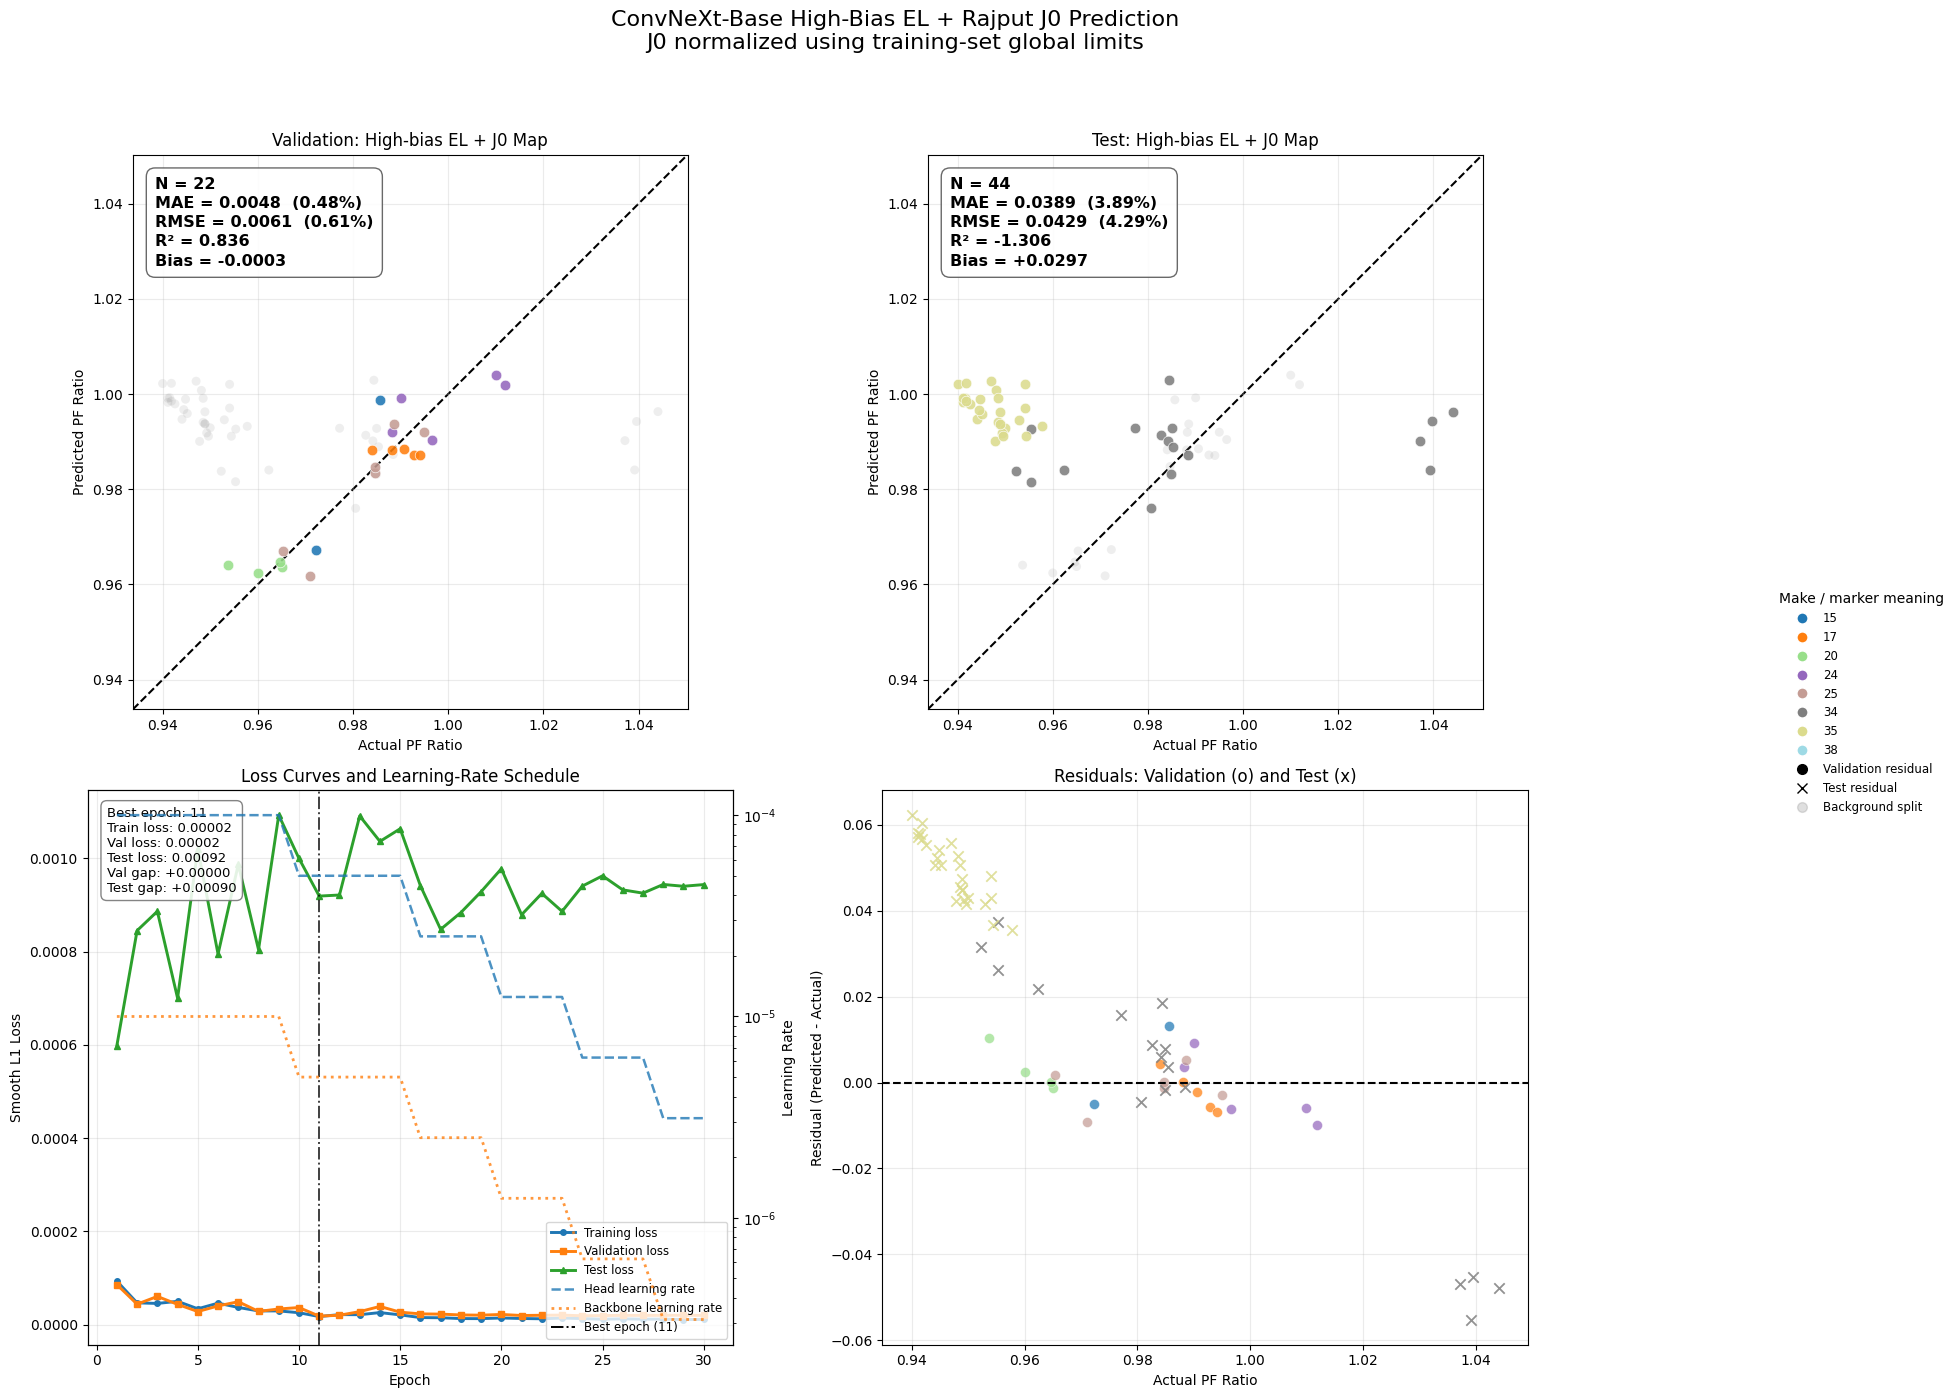


Saved:
- results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_normal_trainval_unseen_make_test_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# ConvNext 60_72_96

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 387
Rows removed due to missing high image or J0 map: 203

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

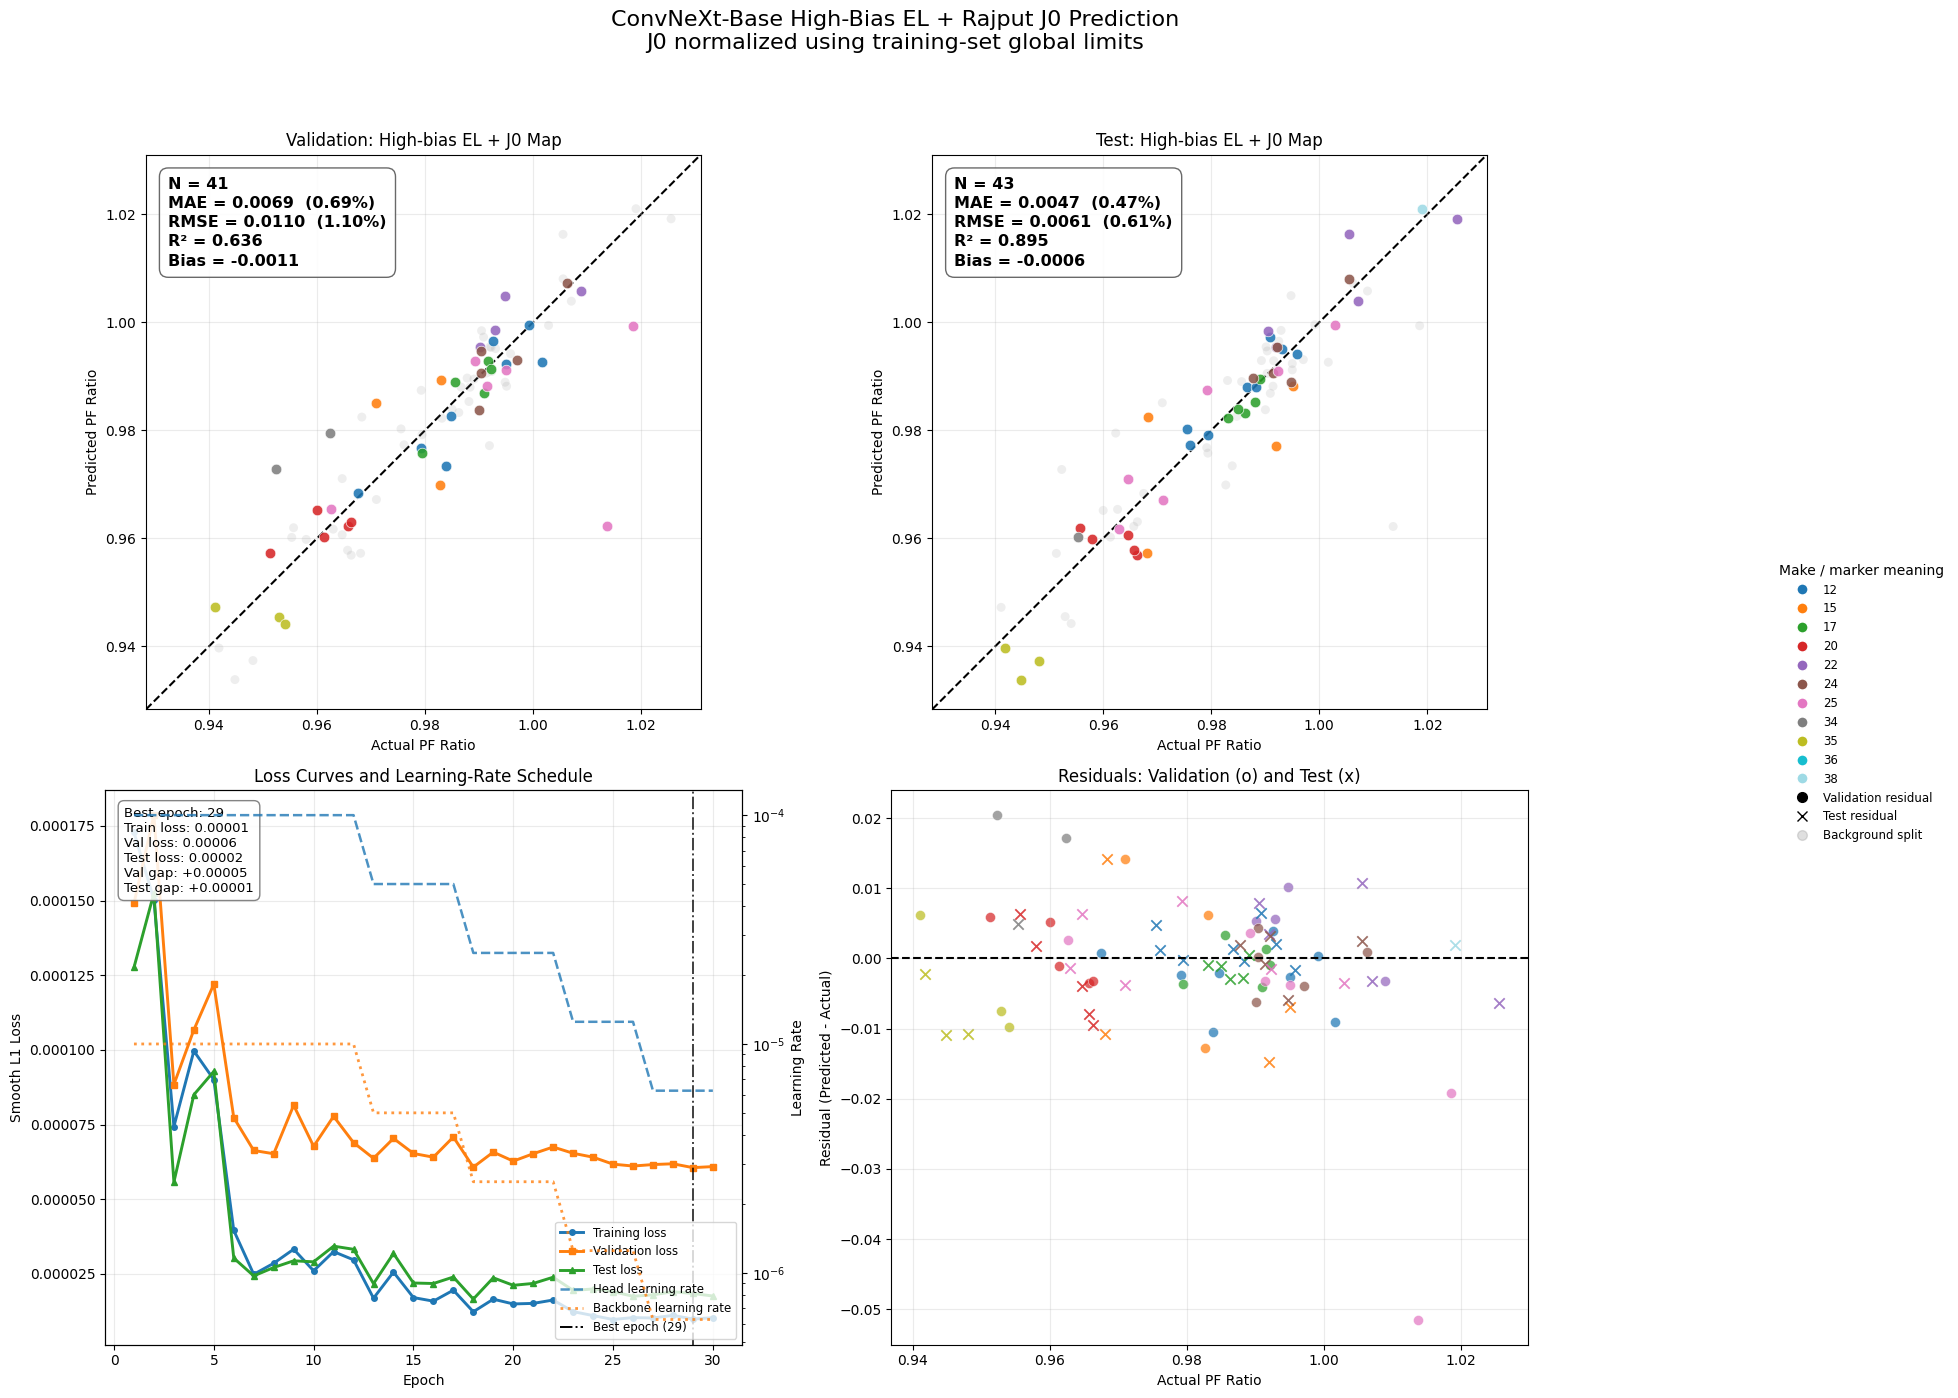


Saved:
- results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# Buat Voc

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Saved CSV with PF_Voc column: AnonDB_80_10_10_seed42_with_PF_Voc.csv
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 387
Rows removed due to missing high image or J0 map: 203

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path    PF_Voc  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.996094  
1  c:

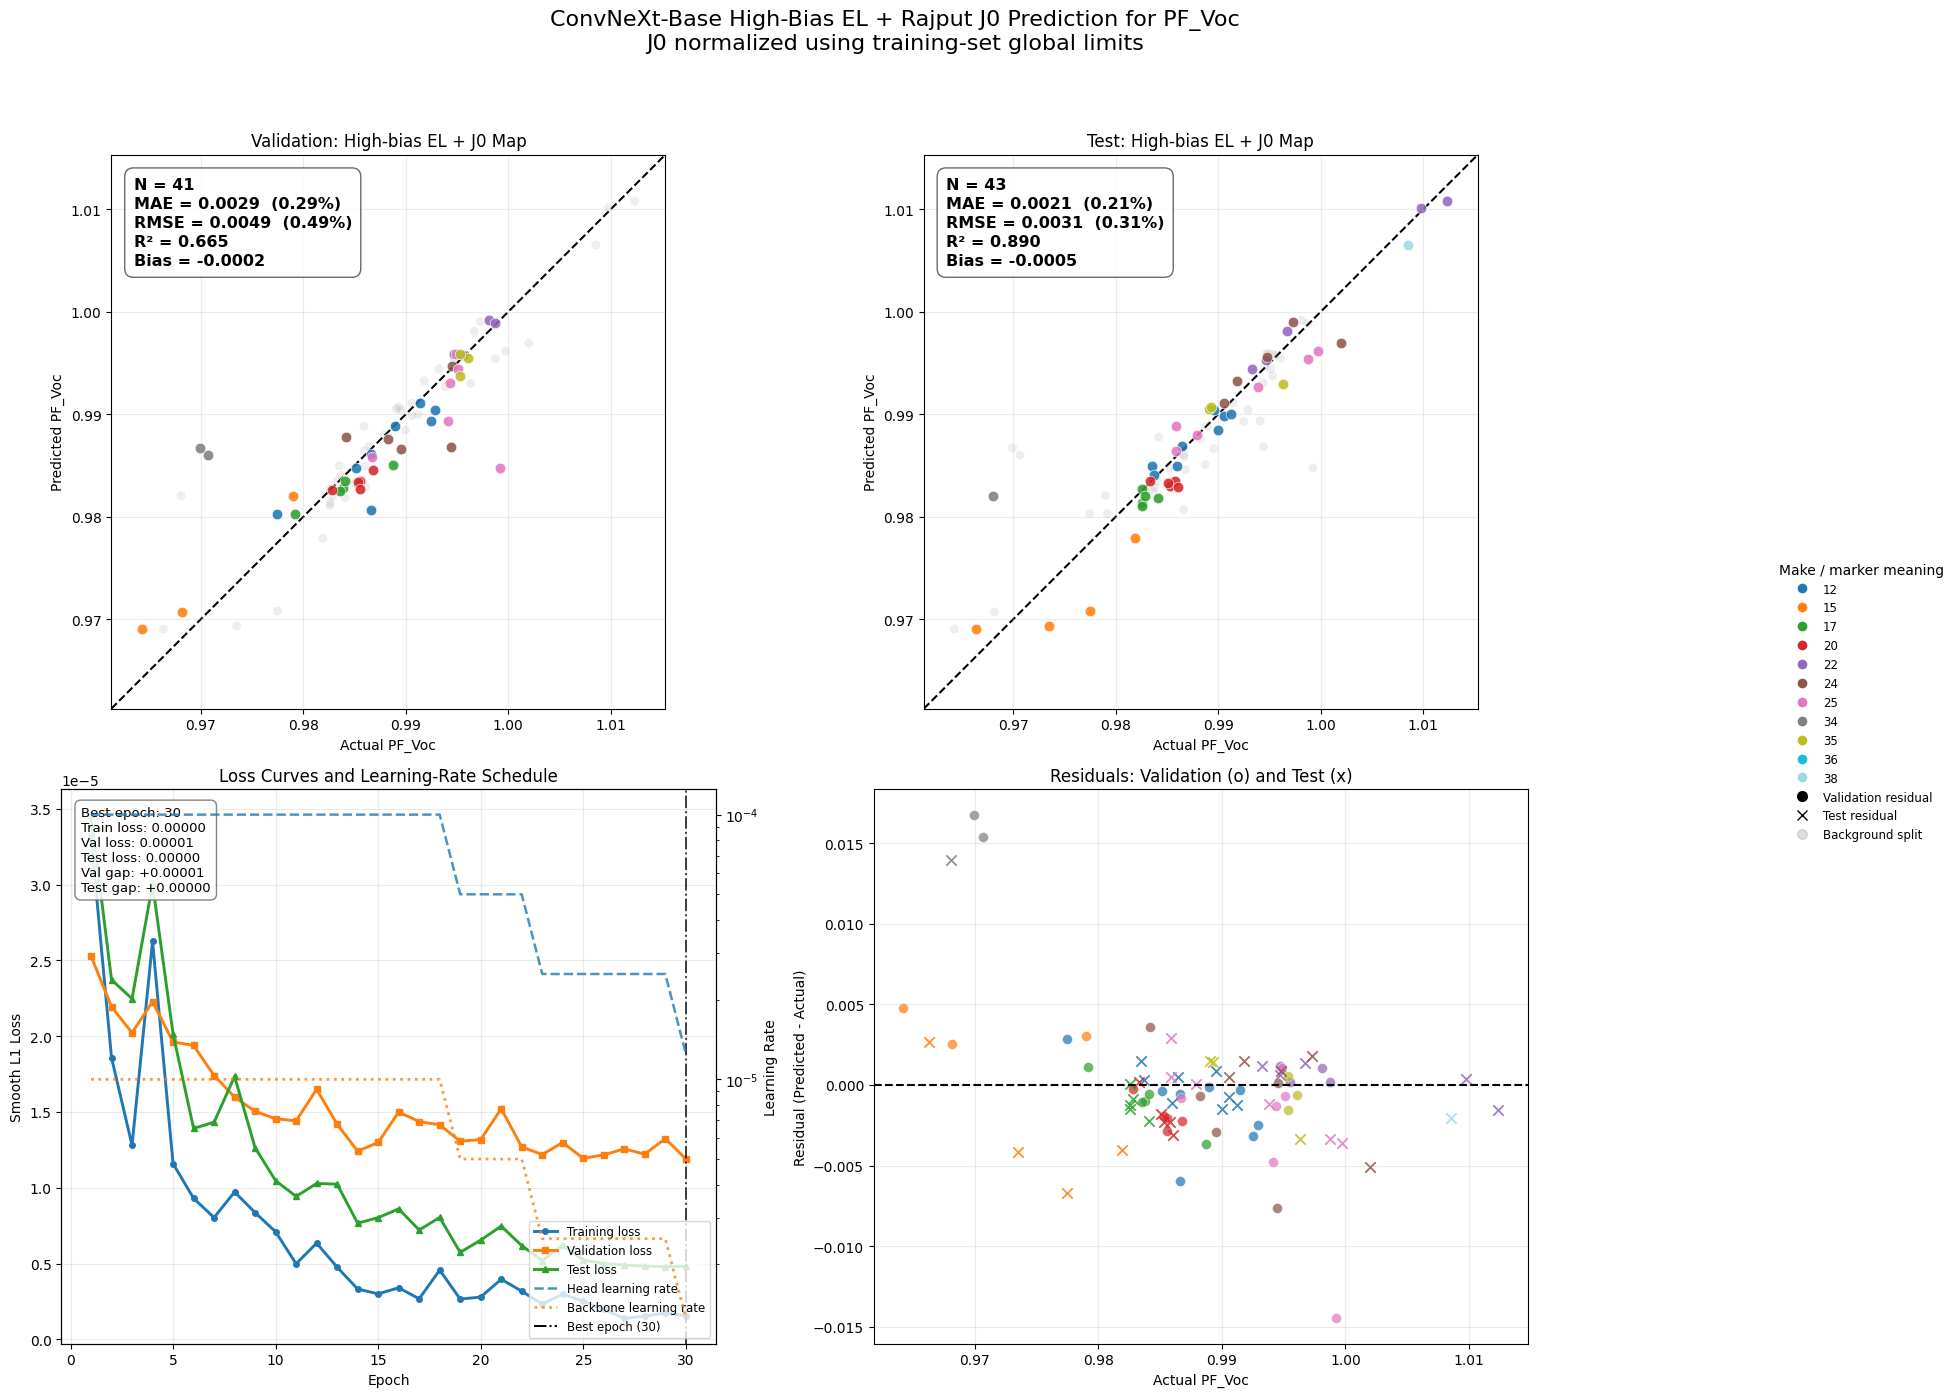


Saved:
- results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv
- convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [3]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Voc_(V)",
        "Nameplate_Voc_(V)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Voc_(V)"] = pd.to_numeric(df["Voc_(V)"], errors="coerce")
    df["Nameplate_Voc_(V)"] = pd.to_numeric(
        df["Nameplate_Voc_(V)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Voc_(V)"].notna()
        & (df["Nameplate_Voc_(V)"] > 0)
        & df["Voc_(V)"].notna()
    ].copy()

    df["PF_Voc"] = df["Voc_(V)"] / df["Nameplate_Voc_(V)"]

    # Save a copy of the input table with the new target column for reproducibility.
    csv_with_target_path = os.path.splitext(csv_path)[0] + "_with_PF_Voc.csv"
    df.to_csv(csv_with_target_path, index=False)
    print(f"Saved CSV with PF_Voc column: {csv_with_target_path}")

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "PF_Voc",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["PF_Voc"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.85, max_val=1.15):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.85,
        max_val=1.15,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_voc"].to_numpy())
        values.extend(df["predicted_pf_voc"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_voc"],
        background_df["predicted_pf_voc"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["predicted_pf_voc"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Predicted PF_Voc")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_voc"].to_numpy()
    predicted = focus_df["predicted_pf_voc"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_voc"] = trues
    results["predicted_pf_voc"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_voc"].to_numpy()
        predicted = group["predicted_pf_voc"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction for PF_Voc\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv"
    model_path = "convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# kita coba lagi

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Saved CSV with PF_Voc column: AnonDB_80_10_10_seed42_with_PF_Voc.csv
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path    PF_Voc  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.996094  
1  c:

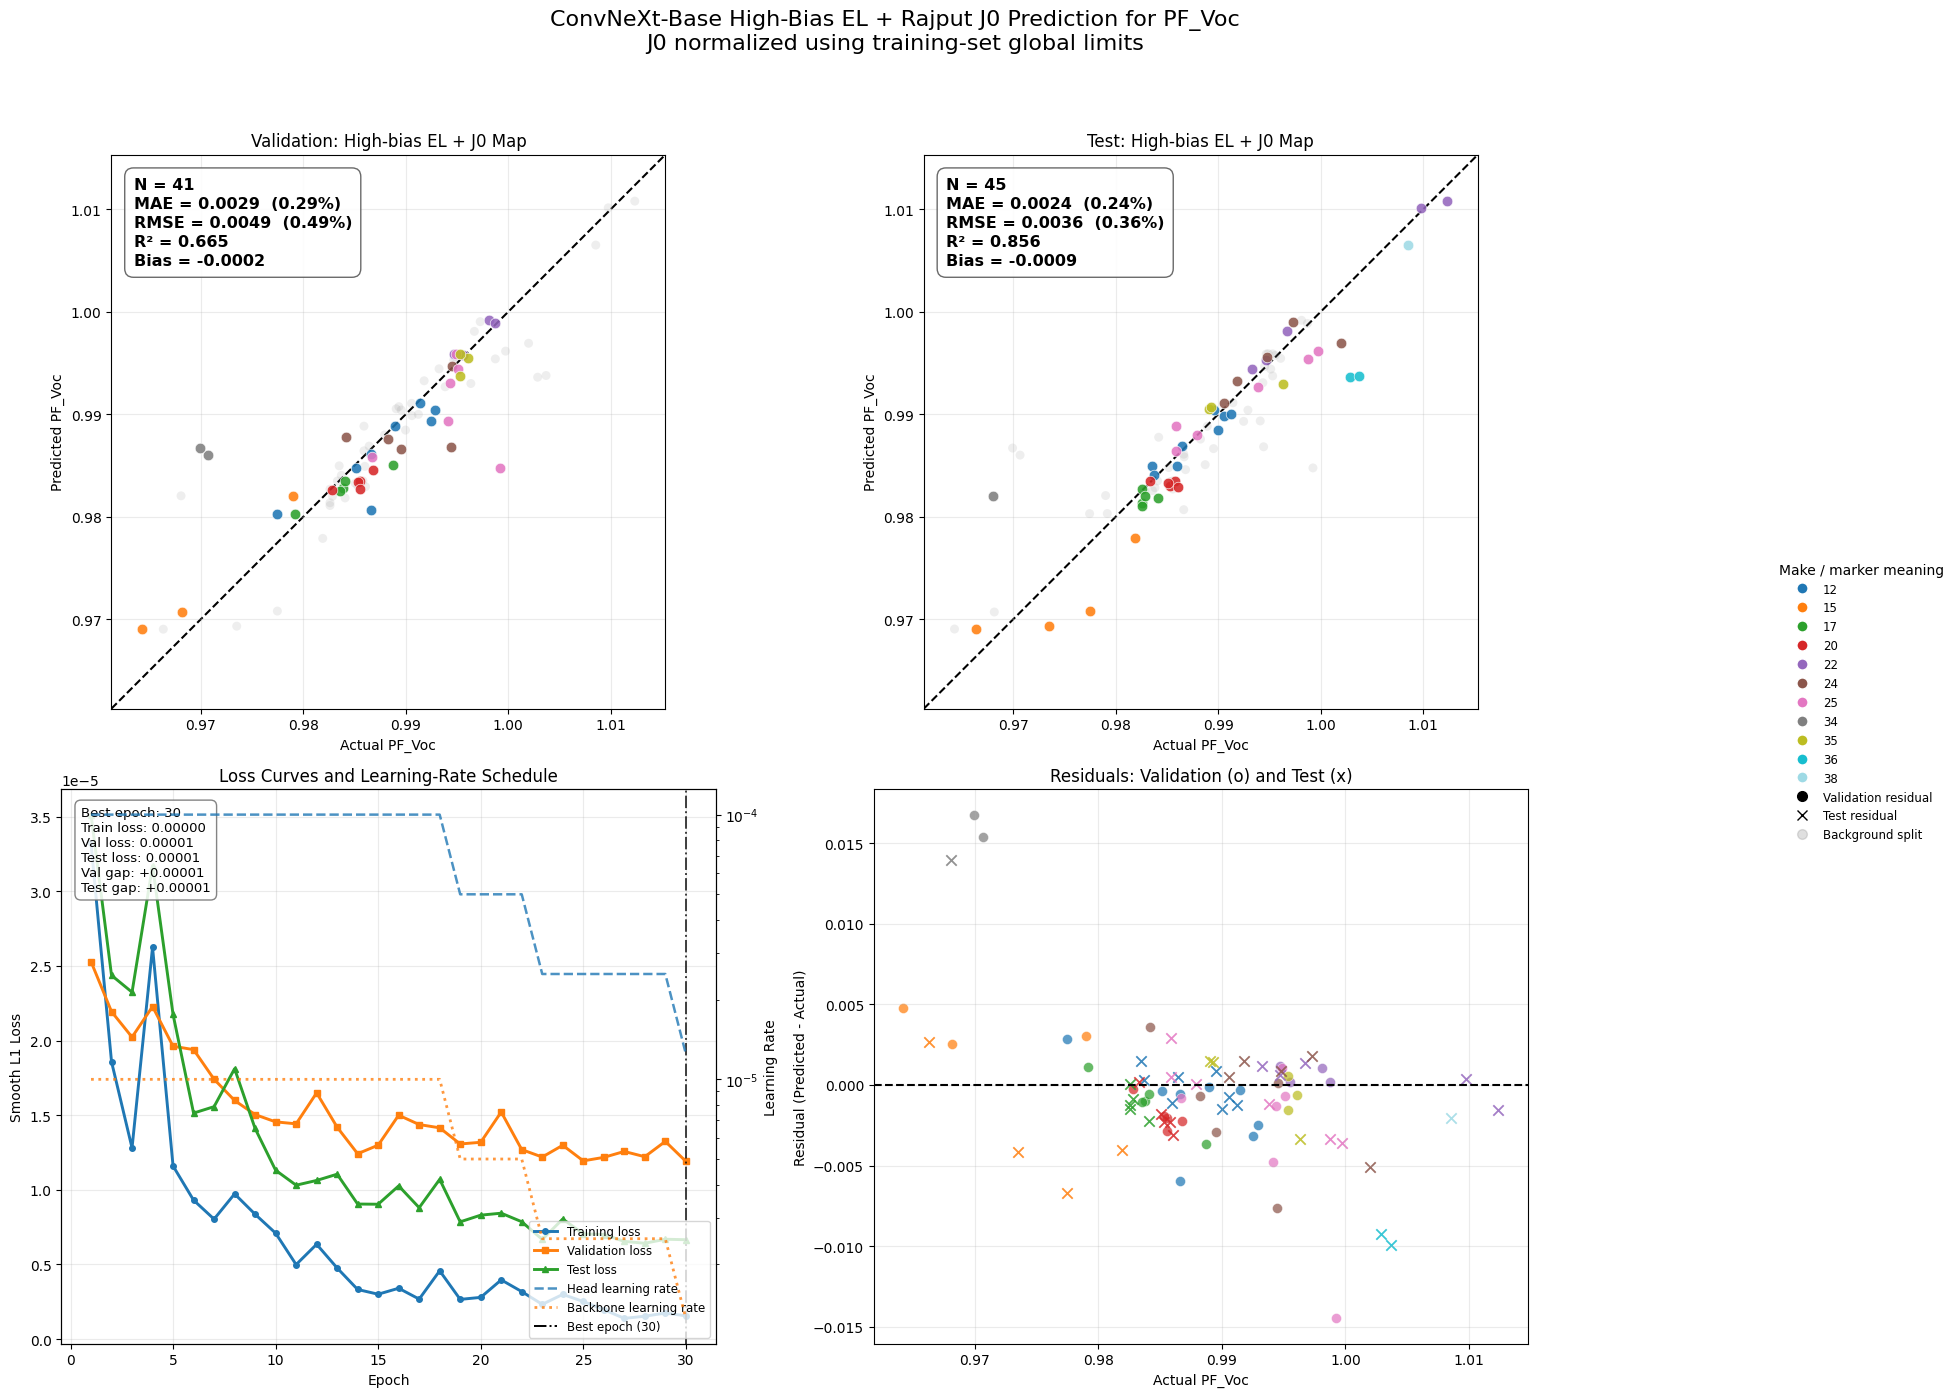


Saved:
- results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv
- convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Voc_(V)",
        "Nameplate_Voc_(V)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Voc_(V)"] = pd.to_numeric(df["Voc_(V)"], errors="coerce")
    df["Nameplate_Voc_(V)"] = pd.to_numeric(
        df["Nameplate_Voc_(V)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Voc_(V)"].notna()
        & (df["Nameplate_Voc_(V)"] > 0)
        & df["Voc_(V)"].notna()
    ].copy()

    df["PF_Voc"] = df["Voc_(V)"] / df["Nameplate_Voc_(V)"]

    # Save a copy of the input table with the new target column for reproducibility.
    csv_with_target_path = os.path.splitext(csv_path)[0] + "_with_PF_Voc.csv"
    df.to_csv(csv_with_target_path, index=False)
    print(f"Saved CSV with PF_Voc column: {csv_with_target_path}")

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "PF_Voc",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["PF_Voc"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.85, max_val=1.15):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.85,
        max_val=1.15,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_voc"].to_numpy())
        values.extend(df["predicted_pf_voc"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_voc"],
        background_df["predicted_pf_voc"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["predicted_pf_voc"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Predicted PF_Voc")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_voc"].to_numpy()
    predicted = focus_df["predicted_pf_voc"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_voc"] = trues
    results["predicted_pf_voc"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_voc"].to_numpy()
        predicted = group["predicted_pf_voc"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction for PF_Voc\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv"
    model_path = "convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# ini untuk performance ratio 

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

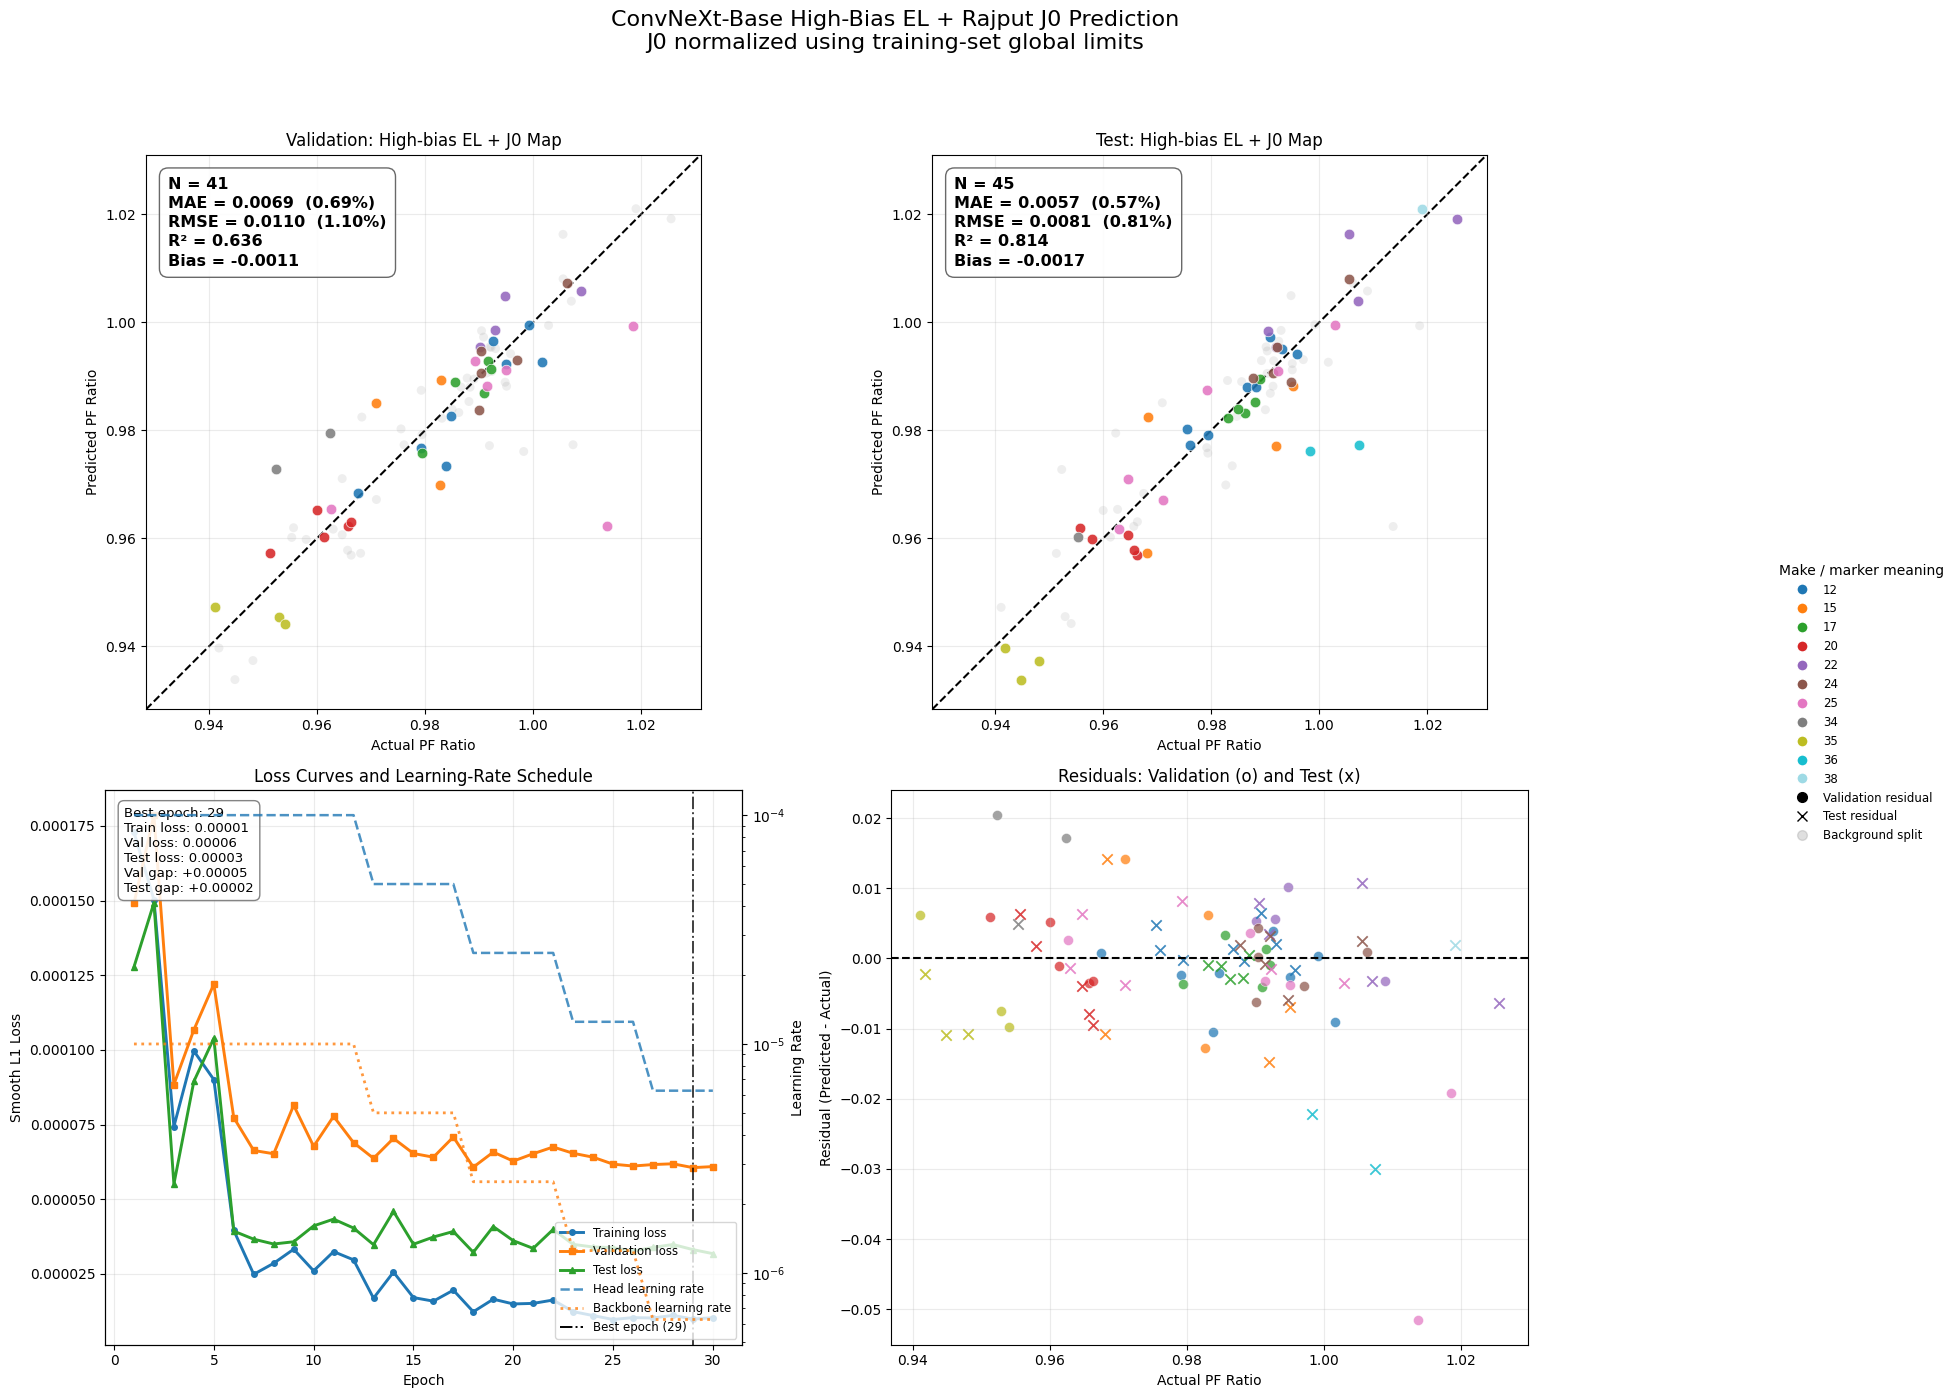


Saved:
- results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Compute global robust normalization limits from the TRAINING SET ONLY.

    The same lower/upper values are then applied to train, validation, and test.
    This avoids leakage from validation/test and preserves absolute scale between
    modules better than per-sample normalization.

    max_pixels_per_map can be set to an integer, for example 20000, to speed up
    percentile calculation. None uses all resized J0 pixels from the training set.
    """
    print("\nComputing global J0 normalization limits from training set only...")

    all_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        finite = j0_resized[np.isfinite(j0_resized)].astype(np.float32)

        if finite.size == 0:
            continue

        if max_pixels_per_map is not None and finite.size > max_pixels_per_map:
            sampled_idx = rng.choice(
                finite.size,
                size=max_pixels_per_map,
                replace=False,
            )
            finite = finite[sampled_idx]

        all_values.append(finite)

    if len(all_values) == 0:
        raise ValueError("No finite J0 values found in the training set.")

    all_values = np.concatenate(all_values)

    lower = float(np.percentile(all_values, lower_percentile))
    upper = float(np.percentile(all_values, upper_percentile))

    # J0 values can naturally be extremely small, for example around 1e-15.
    # Therefore, do not use an absolute threshold such as 1e-12 here.
    # The limits are invalid only when they are non-finite or not ordered.
    if (not np.isfinite(lower)) or (not np.isfinite(upper)) or (upper <= lower):
        raise ValueError(
            "Invalid global J0 normalization limits. "
            f"lower={lower}, upper={upper}"
        )

    print(f"Training-set J0 lower p{lower_percentile:g}: {lower:.6e}")
    print(f"Training-set J0 upper p{upper_percentile:g}: {upper:.6e}")
    print(f"Training-set J0 pixels used: {all_values.size:,}")

    return {
        "lower": lower,
        "upper": upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "n_pixels": int(all_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Normalize J0 using global training-set limits.

    This is intentionally NOT per-sample normalization.
    """
    lower = norm_params["lower"]
    upper = norm_params["upper"]

    denom = upper - lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(
            f"Invalid normalization denominator: lower={lower}, upper={upper}"
        )

    clipped = np.clip(img.astype(np.float32), lower, upper)
    normalized = (clipped - lower) / denom

    return normalized.astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# bismillah bisa yukkkk

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and Io/J0 map existing: 389
Rows removed due to missing high image or Io/J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             io_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  

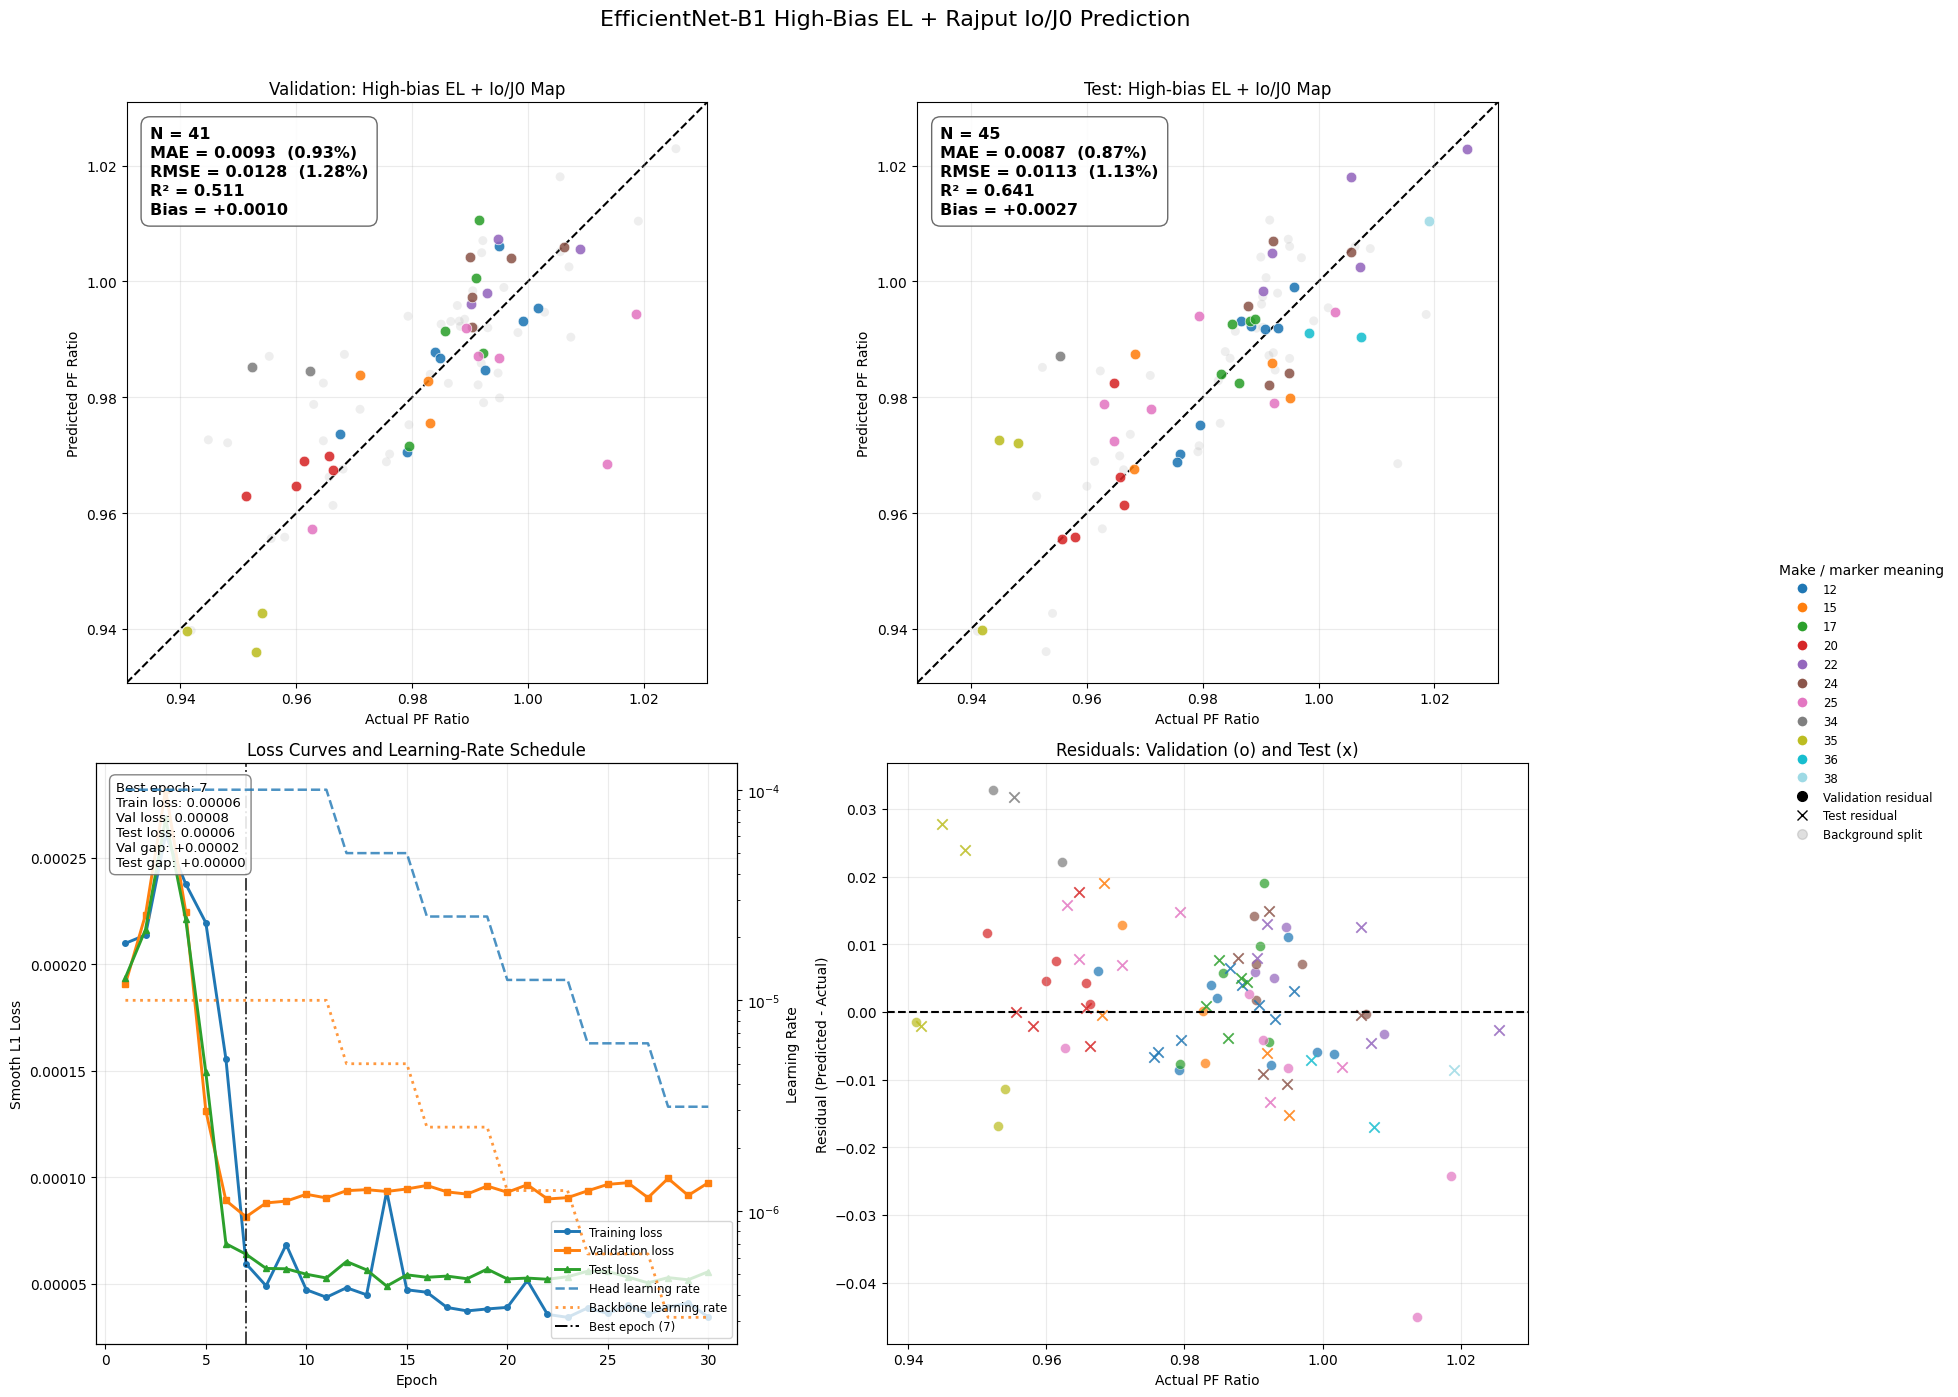


Saved:
- results_effnet_b1_highbias_io_fixedsplit_generalization.png
- validation_predictions_effnet_b1_highbias_io_fixedsplit.csv
- test_predictions_effnet_b1_highbias_io_fixedsplit.csv
- metrics_per_make_effnet_b1_highbias_io_fixedsplit.csv
- training_history_effnet_b1_highbias_io_fixedsplit.csv
- effnet_b1_highbias_io_fixedsplit_best_val_model.pth
Cleanup done.


In [3]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput Io/J0 maps, relative to CSV directory.
# Expected filenames:
#   base_name_Io.tiff
# or fallback:
#   base_name_J0.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# EfficientNet-B1 native input size
IMAGE_SIZE = 240

# If CUDA out of memory, reduce to 8 or 4.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_io_path(elh_path_str, base_dir):
    # Derive Rajput Io map path from ELHPath.
    # Fallback to J0 map if Io map does not exist.
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    io_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    j0_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    if not os.path.exists(io_path) and os.path.exists(j0_fallback):
        io_path = j0_fallback

    return io_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["io_path"] = df["ELHPath"].apply(
        lambda p: derive_io_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["io_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["io_exists"] = df["io_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["io_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and Io/J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or Io/J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "io_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load Io/J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=240):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def robust_normalize_map(img, lower_percentile=1.0, upper_percentile=99.0):
    img = img.astype(np.float32)
    finite = img[np.isfinite(img)]

    if finite.size == 0:
        return np.zeros_like(img, dtype=np.float32)

    low = np.percentile(finite, lower_percentile)
    high = np.percentile(finite, upper_percentile)

    if high - low <= 1e-12:
        return np.zeros_like(img, dtype=np.float32)

    clipped = np.clip(img, low, high)

    return ((clipped - low) / (high - low)).astype(np.float32)


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput Io/J0 map
# =========================================================
class HighBiasIoDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, io map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        self.cache_io = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                io_map = read_physics_map(row["io_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size
                )

                self.cache_io[i] = resize_with_padding_float(
                    io_map,
                    self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_io[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_io.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, io_map):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            io_map = cv2.flip(io_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            io_map = cv2.flip(io_map, 0)

        return high_img, io_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            io_map = self.cache_io[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            io_map = read_physics_map(row["io_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            io_map = resize_with_padding_float(io_map, self.image_size)

        if self.augment:
            high_img, io_map = self.apply_same_augmentation(high_img, io_map)

        # Channel 0: high-bias EL image
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput Io/J0 map
        io_map = robust_normalize_map(io_map)

        high_img = np.expand_dims(high_img, axis=0)
        io_map = np.expand_dims(io_map, axis=0)

        x = np.concatenate([high_img, io_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: EfficientNet-B1, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput Io/J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + Io/J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and Io/J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and Io/J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput Io/J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and Io/J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = HighBiasIoDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_dataset = HighBiasIoDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_dataset = HighBiasIoDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, high-bias EL + Rajput Io/J0 map")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation"
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + Io/J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + Io/J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual"
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 High-Bias EL + Rajput Io/J0 Prediction",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b1_highbias_io_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_highbias_io_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_highbias_io_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_highbias_io_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_highbias_io_fixedsplit.csv"
    model_path = "effnet_b1_highbias_io_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation"
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test"
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# bismillah Jangan salah

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

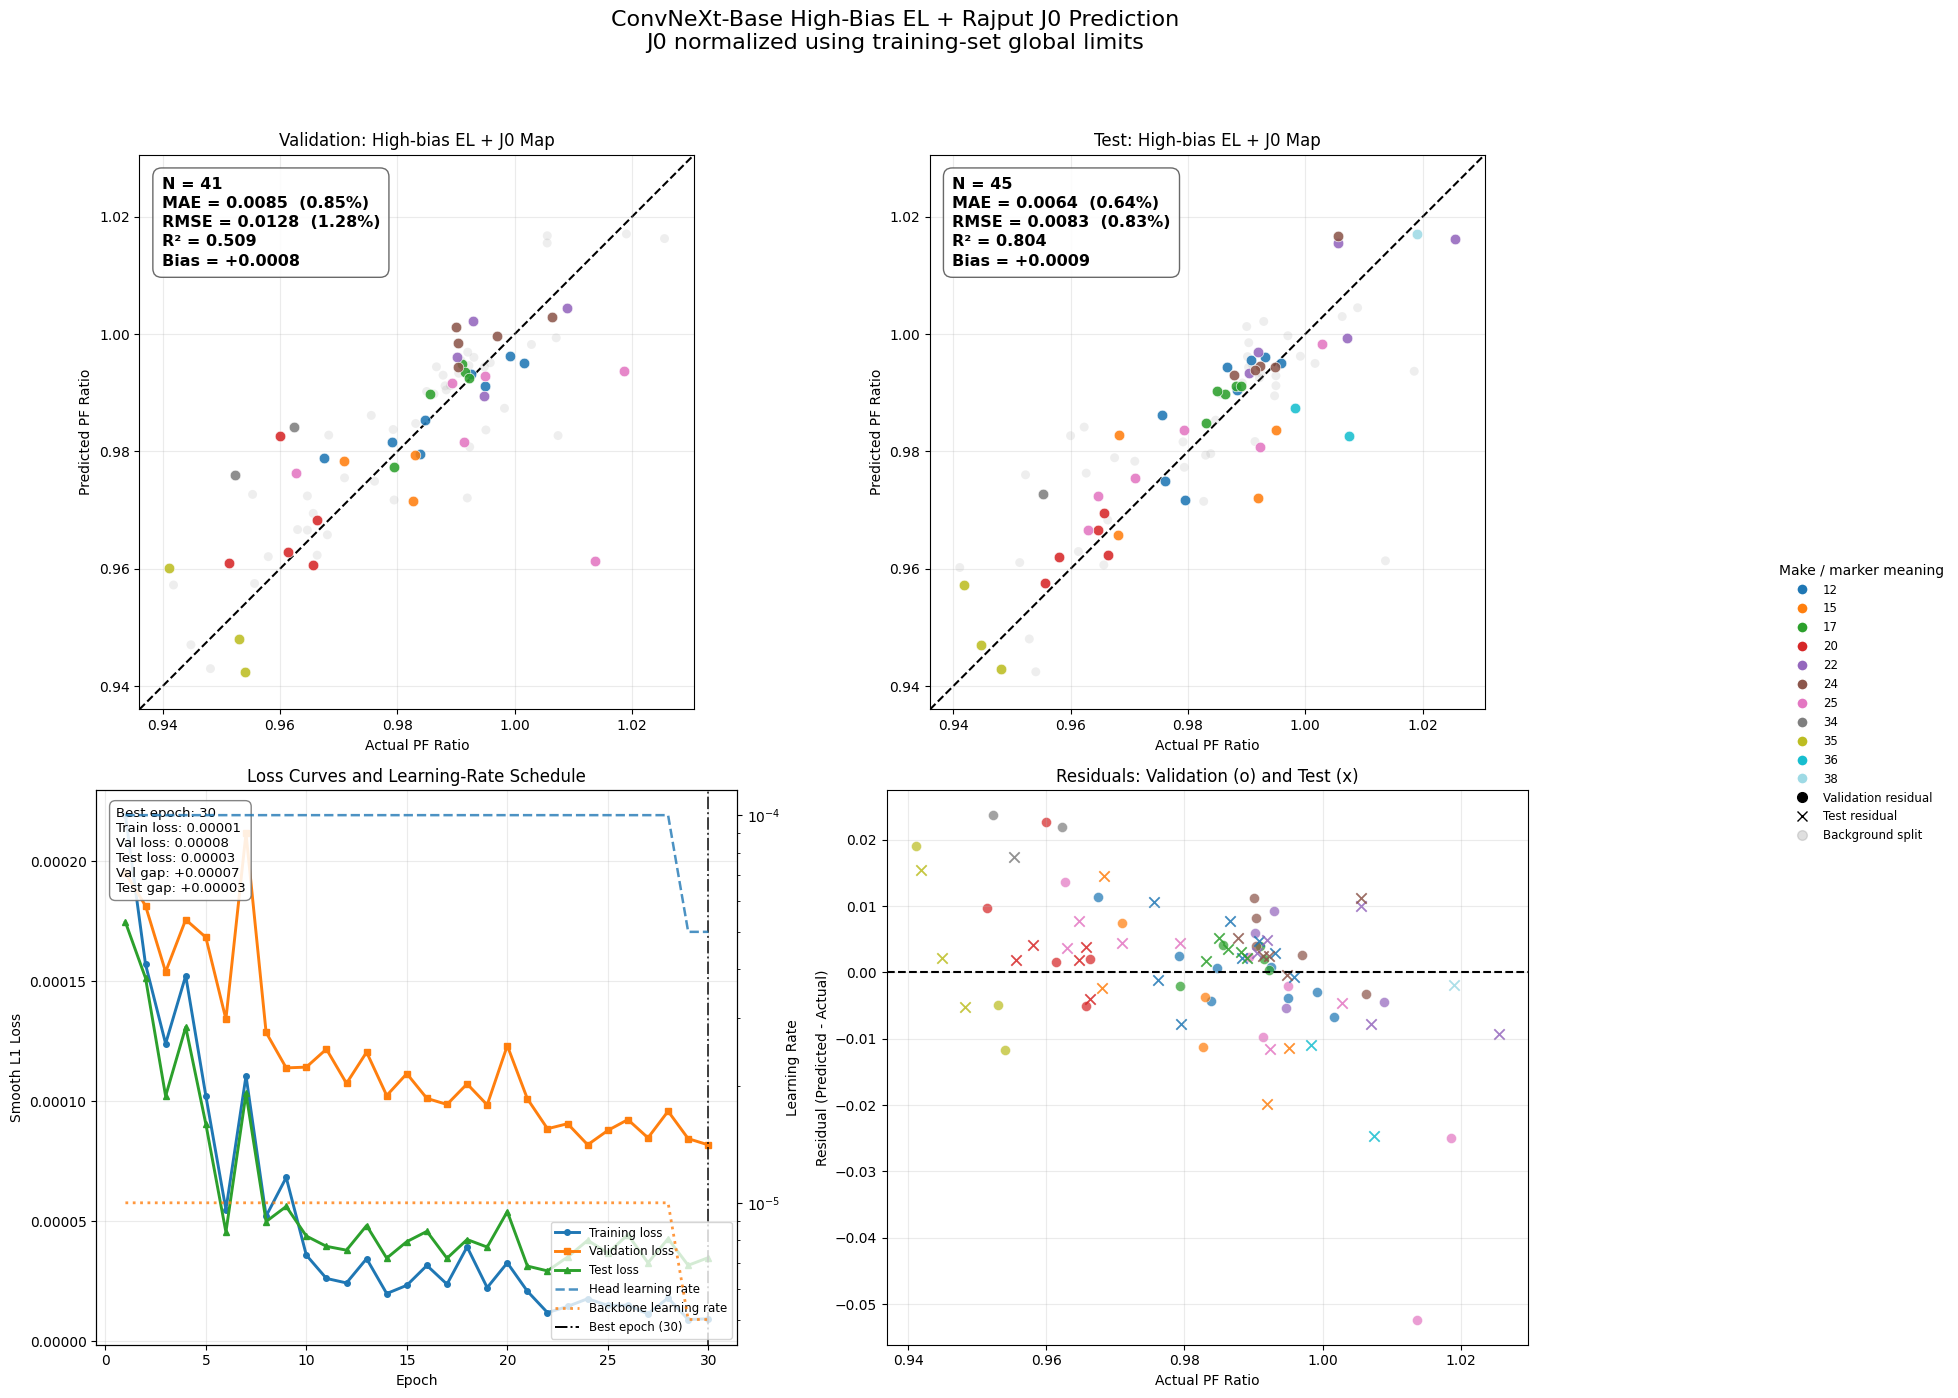


Saved:
- results_convnext_base_highbias_j0_final_generalization.png
- validation_predictions_convnext_base_highbias_j0_final.csv
- test_predictions_convnext_base_highbias_j0_final.csv
- metrics_per_make_convnext_base_highbias_j0_final.csv
- training_history_convnext_base_highbias_j0_final.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0_final.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model_final.pth
Cleanup done.


In [4]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)

def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Robust log-domain J0 limits from the TRAINING SET ONLY.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    Background/padding/invalid pixels (<= J0_FLOOR) are excluded so they
    do not anchor the lower limit.
    """
    print("\nComputing global log-domain J0 limits from training set only...")

    all_log_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        # keep only physically meaningful, strictly positive active pixels
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in the training set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(f"Training-set log10(J0) p{lower_percentile:g}: {log_lower:.4f} "
          f"({10**log_lower:.3e} A/px)")
    print(f"Training-set log10(J0) p{upper_percentile:g}: {log_upper:.4f} "
          f"({10**log_upper:.3e} A/px)")
    print(f"Active training pixels used: {all_log_values.size:,}")

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization to [0, 1] using training-set limits.

    Background/invalid pixels (<= floor) are mapped to 0.0. Active pixels are
    log10-scaled, clipped to the training percentile band, then linearly mapped
    to (0, 1]. This preserves contrast across the J0 spike instead of squashing
    it against the padding value.
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10**log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    # map active pixels into (0, 1]; keep background at exactly 0 so the network
    # can still distinguish "no cell" from "low-J0 cell"
    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_final_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_final.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_final.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_final.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_final.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0_final.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model_final.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# EfficientNet-B1

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

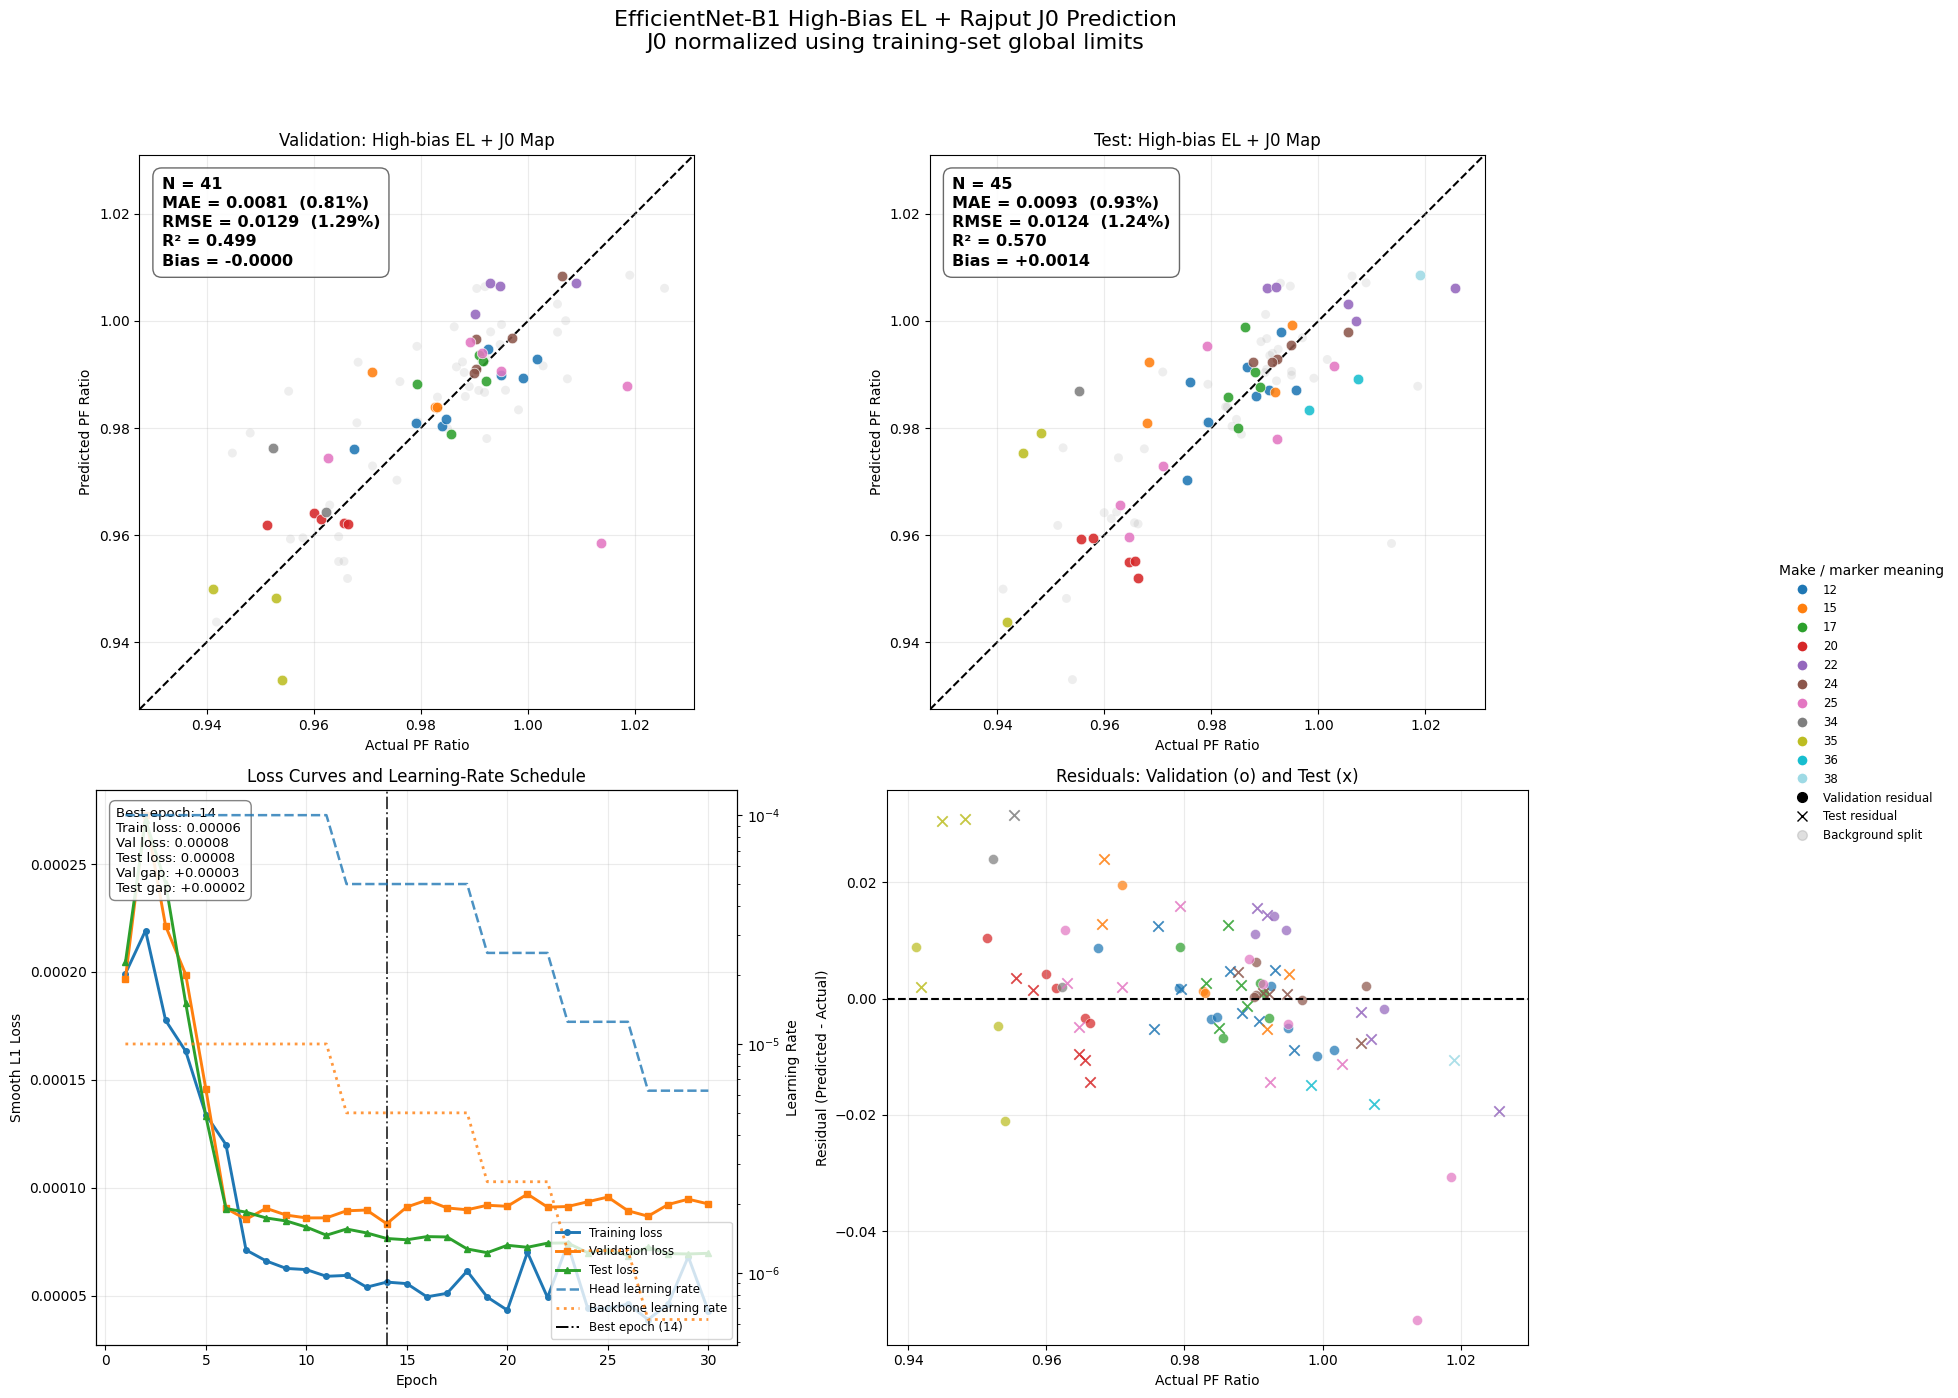


Saved:
- results_effnet_b1_highbias_j0_logtrainnorm_fixedsplit_generalization.png
- validation_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv
- test_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv
- metrics_per_make_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv
- training_history_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv
- j0_train_global_normalization_params_effnet_b1_highbias_j0_logtrainnorm.csv
- effnet_b1_highbias_j0_logtrainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [5]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# EfficientNet-B1 native input size
IMAGE_SIZE = 240

# EfficientNet-B1 is lighter than EfficientNet-B1. For RTX 3050 4GB, start with 16.
# If CUDA out of memory, reduce to 8 or 4.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=240):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=240):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)

def compute_train_global_j0_limits(
    train_dataframe,
    image_size=240,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Robust log-domain J0 limits from the TRAINING SET ONLY.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    Background/padding/invalid pixels (<= J0_FLOOR) are excluded so they
    do not anchor the lower limit.
    """
    print("\nComputing global log-domain J0 limits from training set only...")

    all_log_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        # keep only physically meaningful, strictly positive active pixels
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in the training set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(f"Training-set log10(J0) p{lower_percentile:g}: {log_lower:.4f} "
          f"({10**log_lower:.3e} A/px)")
    print(f"Training-set log10(J0) p{upper_percentile:g}: {log_upper:.4f} "
          f"({10**log_upper:.3e} A/px)")
    print(f"Active training pixels used: {all_log_values.size:,}")

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization to [0, 1] using training-set limits.

    Background/invalid pixels (<= floor) are mapped to 0.0. Active pixels are
    log10-scaled, clipped to the training percentile band, then linearly mapped
    to (0, 1]. This preserves contrast across the J0 spike instead of squashing
    it against the padding value.
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10**log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    # map active pixels into (0, 1]; keep background at exactly 0 so the network
    # can still distinguish "no cell" from "low-J0 cell"
    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=240,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: EfficientNet-B1, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """
    EfficientNet-B1 modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    # EfficientNet stem convolution: model.features[0][0]
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # EfficientNet classifier: Dropout + Linear
    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_effnet_b1_highbias_j0_logtrainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_effnet_b1_highbias_j0_logtrainnorm.csv"
    model_path = "effnet_b1_highbias_j0_logtrainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# VOC jangan salah

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Saved CSV with PF_Voc column: AnonDB_80_10_10_seed42_with_PF_Voc.csv
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path    PF_Voc  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.996094  
1  c:

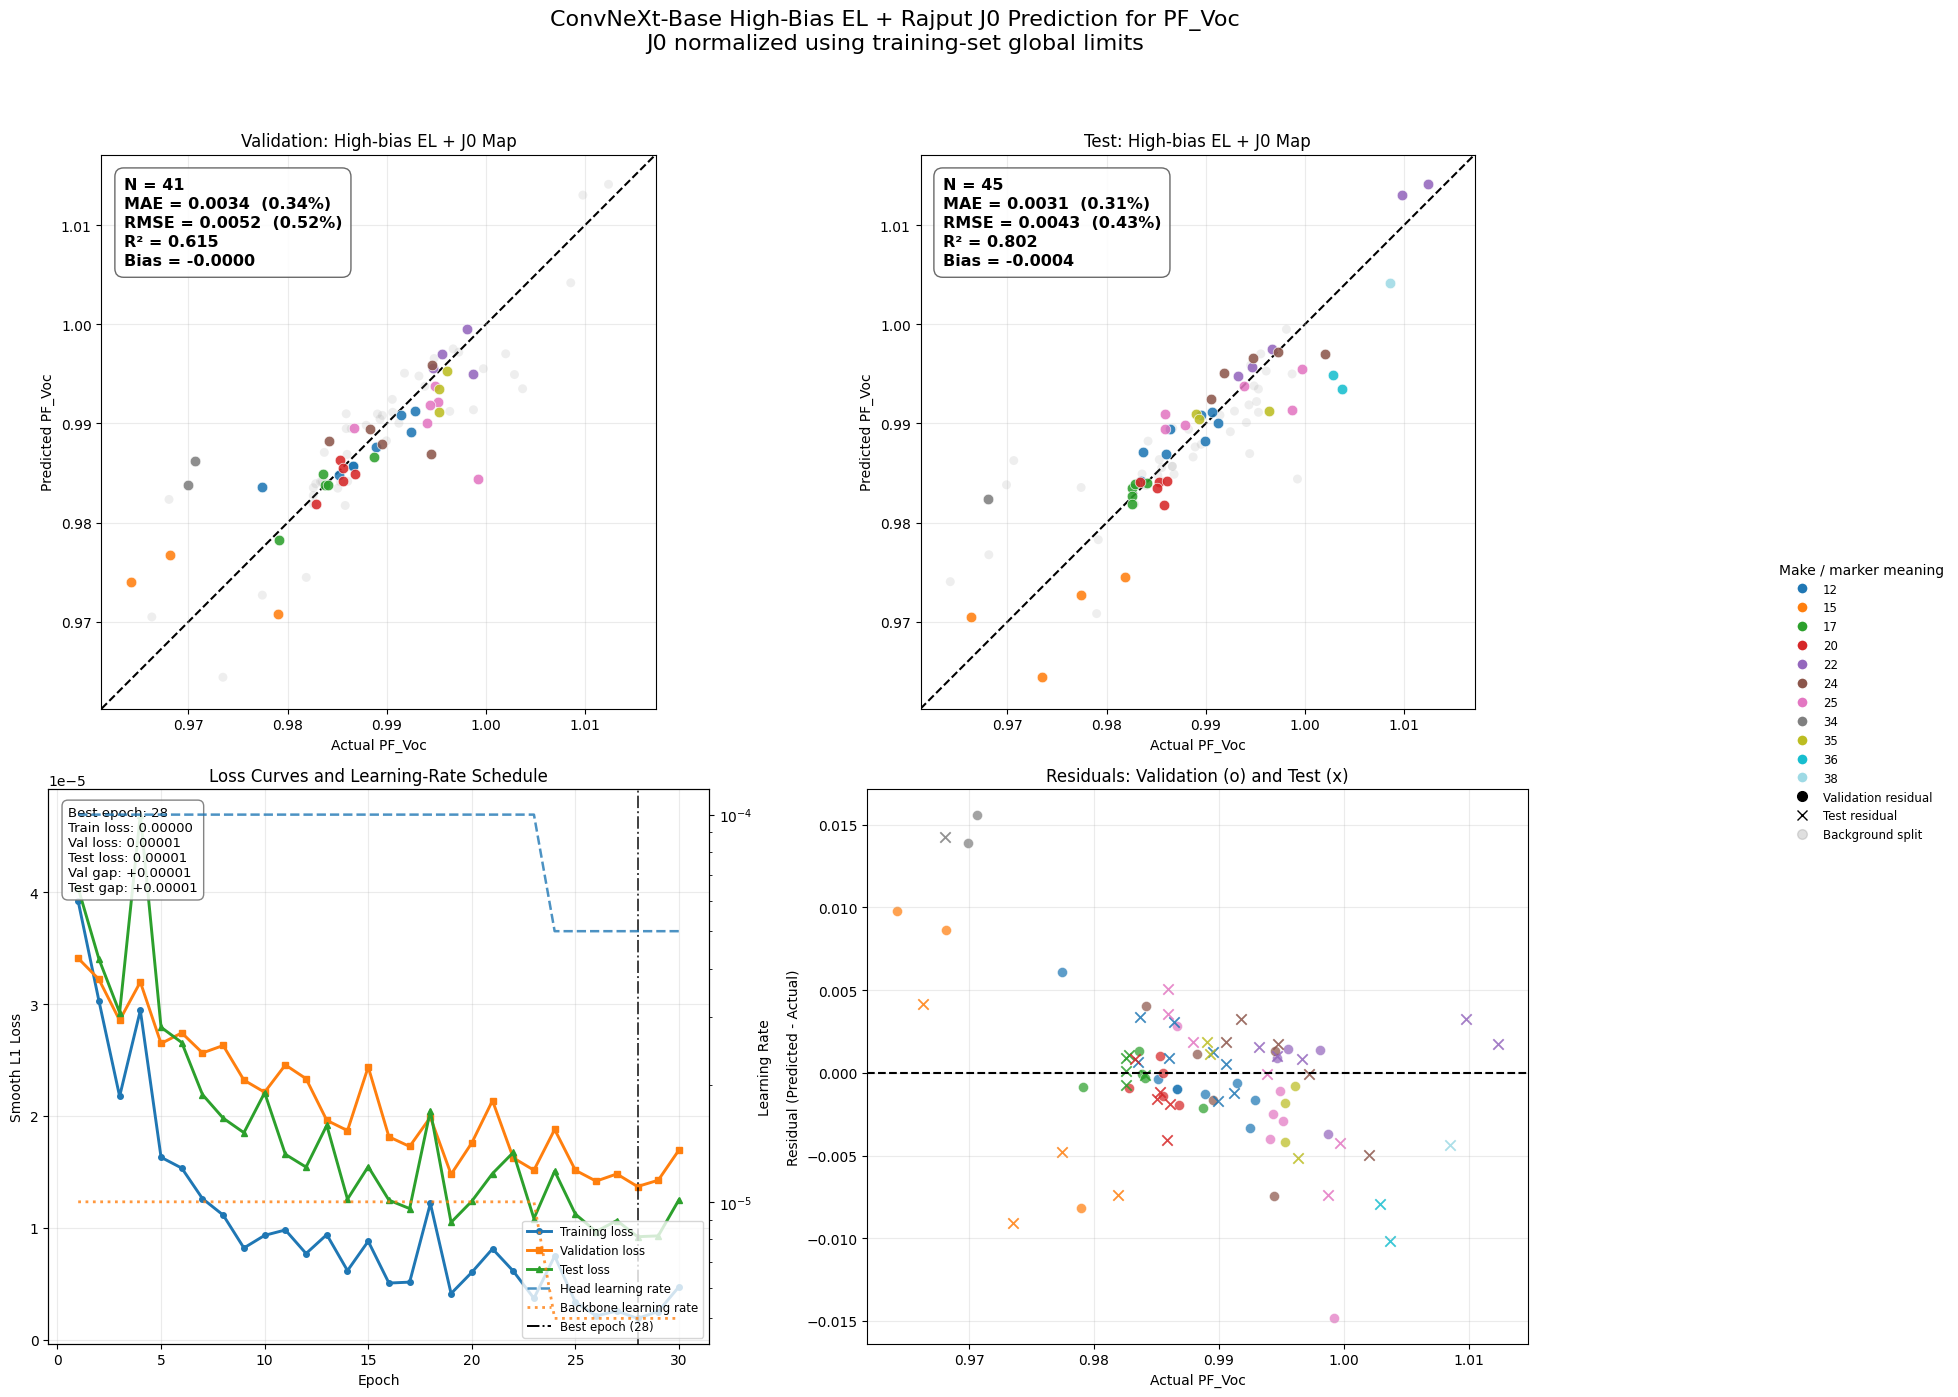


Saved:
- results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png
- validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv
- convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Voc_(V)",
        "Nameplate_Voc_(V)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Voc_(V)"] = pd.to_numeric(df["Voc_(V)"], errors="coerce")
    df["Nameplate_Voc_(V)"] = pd.to_numeric(
        df["Nameplate_Voc_(V)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Voc_(V)"].notna()
        & (df["Nameplate_Voc_(V)"] > 0)
        & df["Voc_(V)"].notna()
    ].copy()

    df["PF_Voc"] = df["Voc_(V)"] / df["Nameplate_Voc_(V)"]

    # Save a copy of the input table with the new target column for reproducibility.
    csv_with_target_path = os.path.splitext(csv_path)[0] + "_with_PF_Voc.csv"
    df.to_csv(csv_with_target_path, index=False)
    print(f"Saved CSV with PF_Voc column: {csv_with_target_path}")

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "PF_Voc",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas

J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)

def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Robust log-domain J0 limits from the TRAINING SET ONLY.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    Background/padding/invalid pixels (<= J0_FLOOR) are excluded so they
    do not anchor the lower limit.
    """
    print("\nComputing global log-domain J0 limits from training set only...")

    all_log_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        # keep only physically meaningful, strictly positive active pixels
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in the training set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(f"Training-set log10(J0) p{lower_percentile:g}: {log_lower:.4f} "
          f"({10**log_lower:.3e} A/px)")
    print(f"Training-set log10(J0) p{upper_percentile:g}: {log_upper:.4f} "
          f"({10**log_upper:.3e} A/px)")
    print(f"Active training pixels used: {all_log_values.size:,}")

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization to [0, 1] using training-set limits.

    Background/invalid pixels (<= floor) are mapped to 0.0. Active pixels are
    log10-scaled, clipped to the training percentile band, then linearly mapped
    to (0, 1]. This preserves contrast across the J0 spike instead of squashing
    it against the padding value.
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10**log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    # map active pixels into (0, 1]; keep background at exactly 0 so the network
    # can still distinguish "no cell" from "low-J0 cell"
    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["PF_Voc"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.85, max_val=1.15):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.85,
        max_val=1.15,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_voc"].to_numpy())
        values.extend(df["predicted_pf_voc"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_voc"],
        background_df["predicted_pf_voc"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["predicted_pf_voc"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Predicted PF_Voc")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_voc"].to_numpy()
    predicted = focus_df["predicted_pf_voc"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_voc"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF_Voc")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_voc"] = trues
    results["predicted_pf_voc"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_voc"].to_numpy()
        predicted = group["predicted_pf_voc"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction for PF_Voc\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0_PF_Voc.csv"
    model_path = "convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


# Tes generalisasi 

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file/map filtering: 590
Rows with both high-bias image and J0 map existing: 389
Rows removed due to missing high image or J0 map: 201

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Use

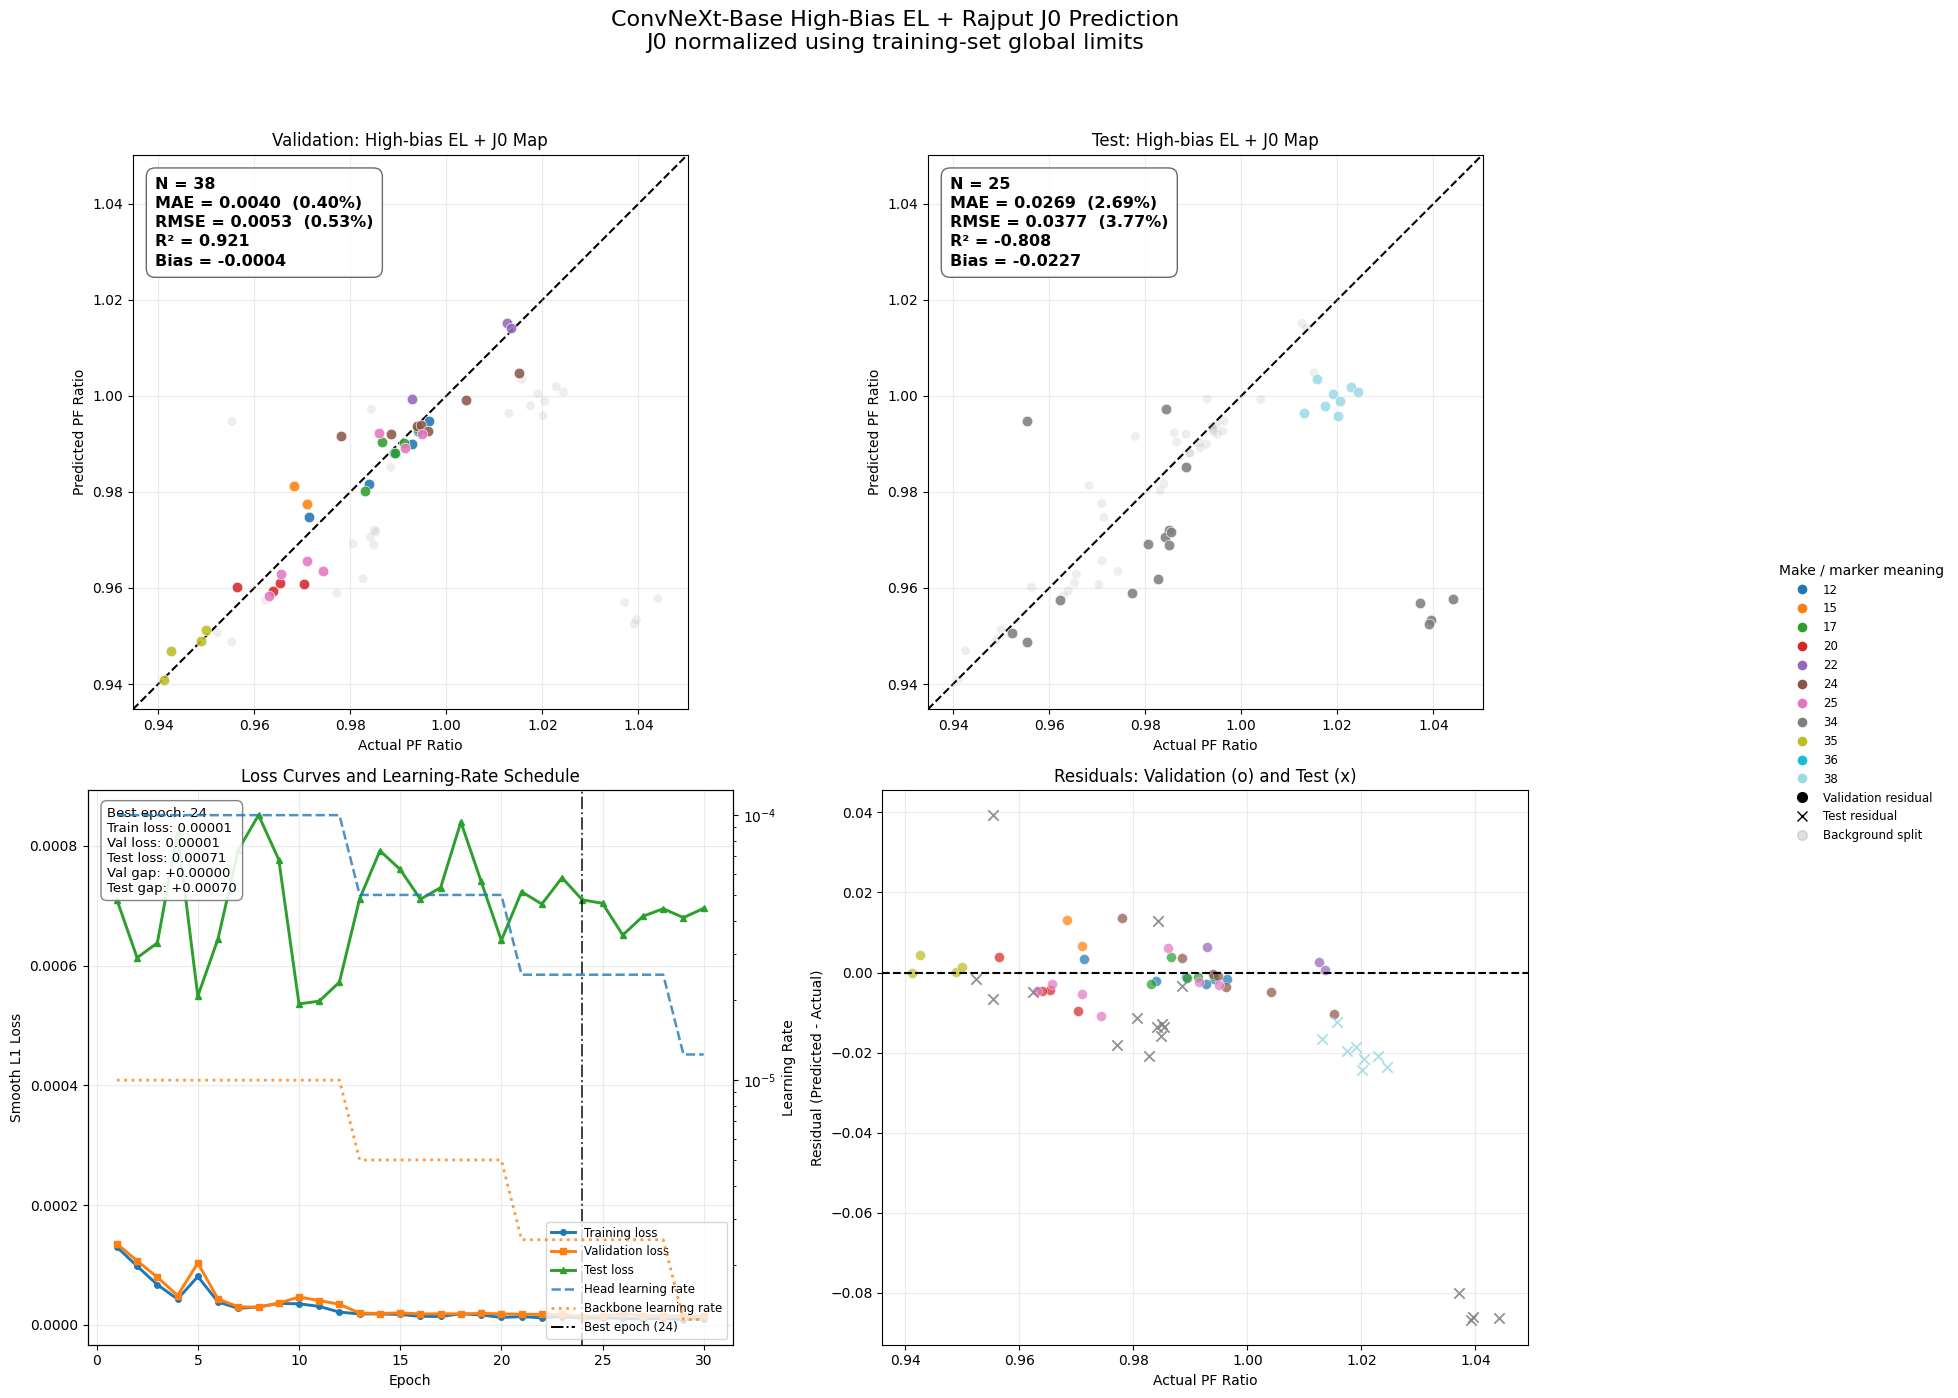


Saved:
- results_convnext_base_highbias_j0_general3438_generalization.png
- validation_predictions_convnext_base_highbias_j0_general3438.csv
- test_predictions_convnext_base_highbias_j0_general3438.csv
- metrics_per_make_convnext_base_highbias_j0_general3438.csv
- training_history_convnext_base_highbias_j0_general3438.csv
- j0_train_global_normalization_params_convnext_base_highbias_j0_general3438.csv
- convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model_general3438.pth
Cleanup done.


In [5]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_test_make34_38_trainval_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

# Folder containing Rajput J0 maps, relative to CSV directory.
# Expected filename:
#   base_name_J0.tiff
# Fallback for compatibility:
#   base_name_Io.tiff
PHYSICS_MAP_DIR = "J0_Rs"

# ConvNeXt-Base native input size
IMAGE_SIZE = 224

# ConvNeXt-Base is heavy. For RTX 3050 4GB, start with 2.
# If CUDA out of memory, reduce to 1.
BATCH_SIZE = 2

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# J0 normalization is computed from the whole TRAINING SET only.
# These same values are used for train, validation, and test.
J0_LOWER_PERCENTILE = 1.0
J0_UPPER_PERCENTILE = 99.0
# Set this to an integer such as 20000 if percentile calculation is slow.
# None means use all resized J0 pixels from the training set.
MAX_PIXELS_PER_J0_MAP_FOR_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve EL image paths from the CSV relative to CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """
    Derive Rajput J0 map path from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        J0:      ./J0_Rs/3883_35_1_01272020_J0.tiff

    Compatibility fallback:
        ./J0_Rs/3883_35_1_01272020_Io.tiff
    """
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove the last suffix, usually bias value such as _80 or _20.
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Load fixed-split CSV, compute PF ratio, resolve high-bias image path,
    derive Rajput J0 map path, and retain Make/split information.

    Important:
    The valid dataset is intentionally limited by J0 map availability.
    Some Make categories may disappear after this filtering.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )

    df["j0_path"] = df["ELHPath"].apply(
        lambda p: derive_j0_path(p, base_dir)
    )

    df = df[df["high_path"].notna() & df["j0_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file/map filtering: {total_before}")
    print(f"Rows with both high-bias image and J0 map existing: {total_after}")
    print(f"Rows removed due to missing high image or J0 map: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}

    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "j0_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_high_bias_image(path):
    """Read high-bias EL image as grayscale uint8."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load high-bias EL image: {path}")

    return img


def read_physics_map(path):
    """Read Rajput J0 map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load J0 map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_uint8(img, target_size=224):
    """Preserve aspect ratio and pad uint8 image to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def resize_with_padding_float(img, target_size=224):
    """Preserve aspect ratio and pad float map to square."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


J0_FLOOR = 1e-20  # below this treated as background/invalid (A/px)

def compute_train_global_j0_limits(
    train_dataframe,
    image_size=224,
    lower_percentile=1.0,
    upper_percentile=99.0,
    max_pixels_per_map=None,
):
    """
    Robust log-domain J0 limits from the TRAINING SET ONLY.

    J0 spans several decades and is heavily right-skewed, so limits are
    computed on log10(J0) over active (non-background) pixels only.
    Background/padding/invalid pixels (<= J0_FLOOR) are excluded so they
    do not anchor the lower limit.
    """
    print("\nComputing global log-domain J0 limits from training set only...")

    all_log_values = []
    rng = np.random.default_rng(RANDOM_SEED)

    for _, row in train_dataframe.reset_index(drop=True).iterrows():
        j0_raw = read_physics_map(row["j0_path"])
        j0_resized = resize_with_padding_float(j0_raw, image_size)

        # keep only physically meaningful, strictly positive active pixels
        active = j0_resized[np.isfinite(j0_resized) & (j0_resized > J0_FLOOR)]
        if active.size == 0:
            continue

        log_active = np.log10(active).astype(np.float32)

        if max_pixels_per_map is not None and log_active.size > max_pixels_per_map:
            idx = rng.choice(log_active.size, size=max_pixels_per_map, replace=False)
            log_active = log_active[idx]

        all_log_values.append(log_active)

    if len(all_log_values) == 0:
        raise ValueError("No finite positive J0 values found in the training set.")

    all_log_values = np.concatenate(all_log_values)

    log_lower = float(np.percentile(all_log_values, lower_percentile))
    log_upper = float(np.percentile(all_log_values, upper_percentile))

    if (not np.isfinite(log_lower)) or (not np.isfinite(log_upper)) or (log_upper <= log_lower):
        raise ValueError(f"Invalid log J0 limits: lower={log_lower}, upper={log_upper}")

    print(f"Training-set log10(J0) p{lower_percentile:g}: {log_lower:.4f} "
          f"({10**log_lower:.3e} A/px)")
    print(f"Training-set log10(J0) p{upper_percentile:g}: {log_upper:.4f} "
          f"({10**log_upper:.3e} A/px)")
    print(f"Active training pixels used: {all_log_values.size:,}")

    return {
        "log_lower": log_lower,
        "log_upper": log_upper,
        "lower_percentile": lower_percentile,
        "upper_percentile": upper_percentile,
        "j0_floor": J0_FLOOR,
        "n_pixels": int(all_log_values.size),
    }


def normalize_j0_with_train_limits(img, norm_params):
    """
    Log-domain robust normalization to [0, 1] using training-set limits.

    Background/invalid pixels (<= floor) are mapped to 0.0. Active pixels are
    log10-scaled, clipped to the training percentile band, then linearly mapped
    to (0, 1]. This preserves contrast across the J0 spike instead of squashing
    it against the padding value.
    """
    log_lower = norm_params["log_lower"]
    log_upper = norm_params["log_upper"]
    floor = norm_params.get("j0_floor", 1e-20)

    denom = log_upper - log_lower
    if (not np.isfinite(denom)) or (denom <= 0):
        raise ValueError(f"Invalid log limits: lower={log_lower}, upper={log_upper}")

    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    active = np.isfinite(img) & (img > floor)
    log_vals = np.log10(np.clip(img[active], 10**log_lower * 1e-6, None))
    log_vals = np.clip(log_vals, log_lower, log_upper)

    # map active pixels into (0, 1]; keep background at exactly 0 so the network
    # can still distinguish "no cell" from "low-J0 cell"
    out[active] = 0.05 + 0.95 * (log_vals - log_lower) / denom
    return out


# =========================================================
# DATASET: 2-channel high-bias EL + Rajput J0 map
# =========================================================
class HighBiasJ0Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_size=224,
        augment=False,
        preload=False,
        j0_norm_params=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.j0_norm_params = j0_norm_params
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)

        # high image = uint8, J0 map = float32
        expected_mb = (
            n * self.image_size * self.image_size * 1
            + n * self.image_size * self.image_size * 4
        ) / (1024 ** 2)

        print(f"\nPreloading {n} samples into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8,
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32,
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_high_bias_image(row["high_path"])
                j0_map = read_physics_map(row["j0_path"])

                self.cache_high[i] = resize_with_padding_uint8(
                    high_img,
                    self.image_size,
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_map,
                    self.image_size,
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_high.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, high_img, j0_map):
        """
        Apply exactly the same geometric flips to the high-bias image
        and J0 map so that they stay spatially aligned.
        """
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)
            j0_map = cv2.flip(j0_map, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)
            j0_map = cv2.flip(j0_map, 0)

        return high_img, j0_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
            j0_map = self.cache_j0[idx].copy()
        else:
            high_img = read_high_bias_image(row["high_path"])
            j0_map = read_physics_map(row["j0_path"])

            high_img = resize_with_padding_uint8(high_img, self.image_size)
            j0_map = resize_with_padding_float(j0_map, self.image_size)

        if self.augment:
            high_img, j0_map = self.apply_same_augmentation(high_img, j0_map)

        # Channel 0: high-bias EL image, common 0-1 scaling for all samples.
        high_img = high_img.astype(np.float32) / 255.0

        # Channel 1: Rajput J0 map, train-set global normalization.
        if self.j0_norm_params is None:
            raise ValueError(
                "j0_norm_params must be provided. "
                "J0 should be normalized using training-set global limits."
            )
        j0_map = normalize_j0_with_train_limits(j0_map, self.j0_norm_params)

        high_img = np.expand_dims(high_img, axis=0)
        j0_map = np.expand_dims(j0_map, axis=0)

        x = np.concatenate([high_img, j0_map], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified for:
        channel 0 = high-bias EL image
        channel 1 = Rajput J0 map normalized using training-set global limits
    """
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem:
    # model.features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu",
            )

            if old_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier:
    # classifier = LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20,
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    best_epoch_handle = Line2D(
        [0], [0],
        linestyle="-.",
        color="black",
        linewidth=1.4,
        label=f"Best epoch ({best_epoch})",
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Residuals: Validation (o) and Test (x)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # This dataset is expected to be smaller because it is limited by Rajput J0 availability.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid high-bias + J0 samples remain. "
            "Continuing because this may be expected for the Rajput subset."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after high-image and J0 filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after high-image and J0 filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    # Only global split emptiness is a hard error.
    # Some Make categories may disappear because only some modules have Rajput J0 maps.
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(
            "Train, validation, or test split is empty after filtering. "
            "Please check that the fixed split CSV and J0 maps overlap."
        )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # Compute J0 normalization limits from the training set only.
    # These same limits are applied to train, validation, and test.
    j0_norm_params = compute_train_global_j0_limits(
        train_df,
        image_size=IMAGE_SIZE,
        lower_percentile=J0_LOWER_PERCENTILE,
        upper_percentile=J0_UPPER_PERCENTILE,
        max_pixels_per_map=MAX_PIXELS_PER_J0_MAP_FOR_NORM,
    )

    train_dataset = HighBiasJ0Dataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    val_dataset = HighBiasJ0Dataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    test_dataset = HighBiasJ0Dataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM,
        j0_norm_params=j0_norm_params,
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL + Rajput J0 map")
    print("J0 normalization: global training-set percentile limits")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE,
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss - training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss - training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df,
        val_trues,
        val_preds,
        "validation",
    )

    test_results_df = make_prediction_table(
        test_df,
        test_trues,
        test_preds,
        "test",
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: High-bias EL + J0 Map",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: High-bias EL + J0 Map",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1],
        val_results_df,
        test_results_df,
        make_palette,
    )

    make_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="black",
            markersize=7,
            label="Validation residual",
        ),
        Line2D(
            [0], [0],
            marker="x",
            linestyle="None",
            color="black",
            markersize=7,
            label="Test residual",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color="grey",
            alpha=0.25,
            markersize=7,
            label="Background split",
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL + Rajput J0 Prediction\nJ0 normalized using training-set global limits",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    result_fig_path = "results_convnext_base_highbias_j0_general3438_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_j0_general3438.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_j0_general3438.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_j0_general3438.csv"
    history_csv_path = "training_history_convnext_base_highbias_j0_general3438.csv"
    norm_params_path = "j0_train_global_normalization_params_convnext_base_highbias_j0_general3438.csv"
    model_path = "convnext_base_highbias_j0_trainnorm_fixedsplit_best_val_model_general3438.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df,
        "validation",
    )

    test_make_metrics = calculate_metrics_per_make(
        test_results_df,
        "test",
    )

    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics],
        ignore_index=True,
    )

    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )

    history_df.to_csv(history_csv_path, index=False)
    pd.DataFrame([j0_norm_params]).to_csv(norm_params_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {norm_params_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
